# MCP Charts — Executive Summary Style + Extended Analysis

Generates charts and analysis for MCP (Model Context Protocol) automation exposure data.

**Data Sources:**
- `data/mcp_variations/automation_mcp_*.csv` — occupation-level automation metrics (one file per scoring variant)
- `data/mcp_tasks_final_*.csv` — task×occupation level data with MCP ratings and wage info
- `data/mcp_results_*.csv` — per-MCP-server data including upload dates and DWA classifications

**Sections:**
1. Executive Summary Charts (workers, wages by major occupational category)
2. Variant Comparison Matrix (all 12 scoring variants)
3. MCP-Specific Analysis (automation rates, wages, concentration)
4. Task-Level Analysis (MCP rating distributions by occupation)
5. Time Trend Analysis (growth over time, occupational coverage trends)

## Configuration

**Change these variables to customize output.**

In [3]:
# ============================================================
# CONFIGURATION — edit these to change what gets generated
# ============================================================

# Default variant for main charts (filename stem after 'automation_mcp_')
# Options: max_ge_1, max_ge_2, max_ge_3, max_ge_4, max_ge_5,
#          mean_ge_1, mean_ge_2, mean_ge_3, mean_ge_4, mean_ge_5,
#          max_weighted, mean_weighted
DEFAULT_VARIANT = "max_ge_5"

# How many top categories / occupations to show in bar charts
TOP_N_CATEGORIES = 15
TOP_N_OCCUPATIONS = 15

# Output directory (relative to this notebook's location)
OUTPUT_DIR = "../outputs/mcp_charts"

# Data file paths (relative to this notebook's location)
MCP_VARIATIONS_DIR = "../data/mcp_variations"
MCP_RESULTS_FILE   = "../data/mcp_results_2026-02-18.csv"
MCP_TASKS_FILE     = "../data/mcp_tasks_final_2026-02-18.csv"

# Chart styling
MAIN_COLOR = "#3a5f83"
ACCENT_COLOR = "#e07b39"
CHART_SIZE = (17, 9)
FONT_SIZE = 14

# Lato font directory (leave empty string to use system default)
FONT_DIR = r"C:\Users\teddy\Downloads\OAIPR\Technical\AEI Data Other\Lato"

## Imports & Setup

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import os
import re
from textwrap import wrap
from glob import glob

# ── Font setup ──────────────────────────────────────────────
if FONT_DIR and os.path.isdir(FONT_DIR):
    for f in os.listdir(FONT_DIR):
        if f.lower().endswith(".ttf") and "lato" in f.lower():
            fm.fontManager.addfont(os.path.join(FONT_DIR, f))
    plt.rcParams["font.family"] = "Lato"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["font.weight"] = "normal"
sns.set_context("notebook", font_scale=1.0)

# ── Output dir ───────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Charts will be saved to: {os.path.abspath(OUTPUT_DIR)}")

Charts will be saved to: c:\Users\teddy\Downloads\OAIPR\Technical\automation_exposure_analysis\outputs\mcp_charts


## Load Data

In [5]:
# ── Main variant (for exec-summary charts) ───────────────────
variant_path = os.path.join(MCP_VARIATIONS_DIR, f"automation_mcp_{DEFAULT_VARIANT}.csv")
df = pd.read_csv(variant_path)
print(f"Loaded variant: {DEFAULT_VARIANT}  to  {len(df):,} occupations")

# Quality filter: remove rows where AI freq > economy freq (data quality issue)
df_clean = df[df["freq_sum_ai"] <= df["freq_sum_eco"]].copy()
print(f"After quality filter: {len(df_clean):,} occupations")

# ── Task-level data ──────────────────────────────────────────
tasks_df = pd.read_csv(MCP_TASKS_FILE)
print(f"Task-level data: {len(tasks_df):,} task×occupation rows")

# ── MCP results (server-level with upload dates) ─────────────
results_df = pd.read_csv(MCP_RESULTS_FILE)
results_df["uploaded_clean"] = pd.to_datetime(results_df["uploaded_clean"], errors="coerce")
results_df["upload_month"]   = results_df["uploaded_clean"].dt.to_period("M")
print(f"MCP servers: {len(results_df):,} | Date range: {results_df['uploaded_clean'].min().date()} to {results_df['uploaded_clean'].max().date()}")

Loaded variant: max_ge_5  to  878 occupations
After quality filter: 851 occupations
Task-level data: 11,777 task×occupation rows
MCP servers: 10,140 | Date range: 2025-04-19 to 2026-02-16


## Summary Statistics

In [6]:
# ── National totals ──────────────────────────────────────────
total_workers_nat = df_clean["people_automated_nat"].sum()
total_wages_nat   = df_clean["eco_value_nat"].sum()
total_workers_ut  = df_clean["people_automated_ut"].sum()
total_wages_ut    = df_clean["eco_value_ut"].sum()
pct_nat           = (df_clean["ai_task_comp_nat"].sum() / df_clean["task_comp_nat"].sum()) * 100
pct_ut            = (df_clean["ai_task_comp_ut"].sum()  / df_clean["task_comp_ut"].sum())  * 100

print("=" * 60)
print(f"Variant: {DEFAULT_VARIANT}")
print("=" * 60)
print(f"NATIONAL")
print(f"  Workers affected:        {total_workers_nat:>15,.0f}")
print(f"  Wages affected:          ${total_wages_nat/1e9:>13.1f}B")
print(f"  Avg automation rate:     {pct_nat:>13.1f}%")
print()
print(f"UTAH")
print(f"  Workers affected:        {total_workers_ut:>15,.0f}")
print(f"  Wages affected:          ${total_wages_ut/1e9:>13.1f}B")
print(f"  Avg automation rate:     {pct_ut:>13.1f}%")
print()
print(f"MCP SERVERS")
print(f"  Total MCP servers:       {len(results_df):>15,}")
print(f"  Mean DWAs per server:    {results_df['n_dwas_selected'].mean():>15.1f}")
print(f"  Mean tasks per server:   {results_df['n_tasks_sent'].mean():>15.1f}")
print("=" * 60)

# Major occupational category breakdown
cat_summary = (
    df_clean.groupby("major_occ_category")
    .agg(workers_nat=("people_automated_nat", "sum"),
         wages_nat  =("eco_value_nat", "sum"),
         ai_comp    =("ai_task_comp_nat", "sum"),
         tot_comp   =("task_comp_nat", "sum"))
    .assign(pct=lambda x: x.ai_comp / x.tot_comp * 100)
    .sort_values("workers_nat", ascending=False)
    .reset_index()
)
cat_summary["wages_nat_B"] = cat_summary["wages_nat"] / 1e9
print("\nAll major categories (National, sorted by workers affected):")
display(cat_summary[["major_occ_category", "workers_nat", "wages_nat_B", "pct"]]
        .rename(columns={"major_occ_category": "Category",
                         "workers_nat": "Workers",
                         "wages_nat_B": "Wages ($B)",
                         "pct": "Auto %"})
        .style.format({"Workers": "{:,.0f}", "Wages ($B)": "${:.1f}B", "Auto %": "{:.1f}%"}))

Variant: max_ge_5
NATIONAL
  Workers affected:             16,983,736
  Wages affected:          $        880.8B
  Avg automation rate:              11.3%

UTAH
  Workers affected:                194,362
  Wages affected:          $          9.8B
  Avg automation rate:              13.1%

MCP SERVERS
  Total MCP servers:                10,140
  Mean DWAs per server:               13.9
  Mean tasks per server:             118.9

All major categories (National, sorted by workers affected):


,Category,Workers,Wages ($B),Auto %
0,Office and Administrative Support Occupations,"5,953,530",$276.9B,37.3%
1,Sales and Related Occupations,"3,786,407",$138.2B,38.3%
2,Business and Financial Operations Occupations,"1,480,037",$116.4B,11.9%
3,Food Preparation and Serving Related Occupations,"1,135,914",$37.2B,7.3%
4,Computer and Mathematical Occupations,"1,041,461",$102.7B,22.9%
5,Transportation and Material Moving Occupations,"734,670",$31.9B,5.7%
6,Educational Instruction and Library Occupations,"717,706",$43.6B,10.4%
7,Healthcare Support Occupations,"550,552",$20.5B,6.1%
8,Healthcare Practitioners and Technical Occupations,"238,307",$12.9B,1.7%
9,Personal Care and Service Occupations,"212,178",$7.7B,5.8%


---
# Section 1: Executive Summary-Style Charts

Same structure as `charts_for_executive_summary_oct_2025.ipynb` but using MCP data.

### 1a. Workers Affected by Major Occupational Category (National)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\3304481451.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)


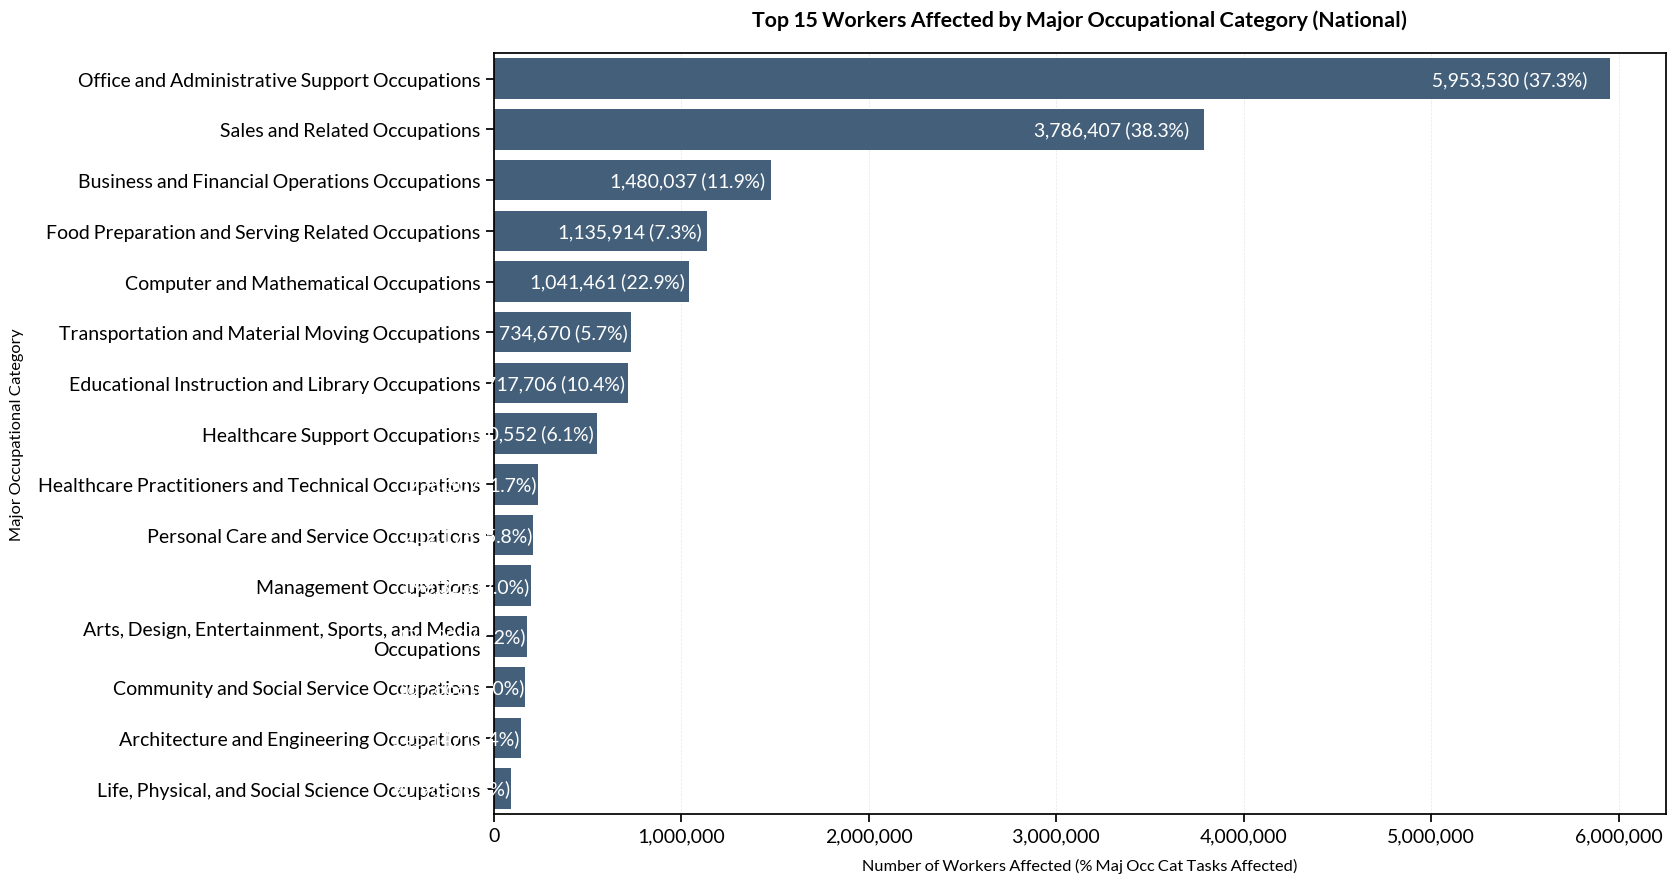

Saved: 01a_Workers_by_Occ_Category_National_max_ge_5.png


In [7]:
grouped = (
    df_clean.groupby("major_occ_category")
    .agg(people_automated_nat=("people_automated_nat", "sum"),
         ai_task_comp_nat     =("ai_task_comp_nat",     "sum"),
         task_comp_nat        =("task_comp_nat",        "sum"))
    .assign(pct=lambda x: x.ai_task_comp_nat / x.task_comp_nat * 100)
    .sort_values("people_automated_nat", ascending=False)
    .head(TOP_N_CATEGORIES)
    .reset_index()
)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=grouped, x="people_automated_nat", y="major_occ_category",
            color=MAIN_COLOR, ax=ax)

for i, row in grouped.iterrows():
    ax.text(row.people_automated_nat * 0.98, i,
            f' {row.people_automated_nat:,.0f} ({row.pct:.1f}%)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)
plt.subplots_adjust(left=0.38)
ax.set_title(f"Top {TOP_N_CATEGORIES} Workers Affected by Major Occupational Category (National)",
             fontsize=FONT_SIZE * 1.1, fontweight='bold', pad=20)
ax.set_xlabel("Number of Workers Affected (% Maj Occ Cat Tasks Affected)",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Major Occupational Category", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"01a_Workers_by_Occ_Category_National_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 1b. Workers Affected by Major Occupational Category (Utah)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\3010310727.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)


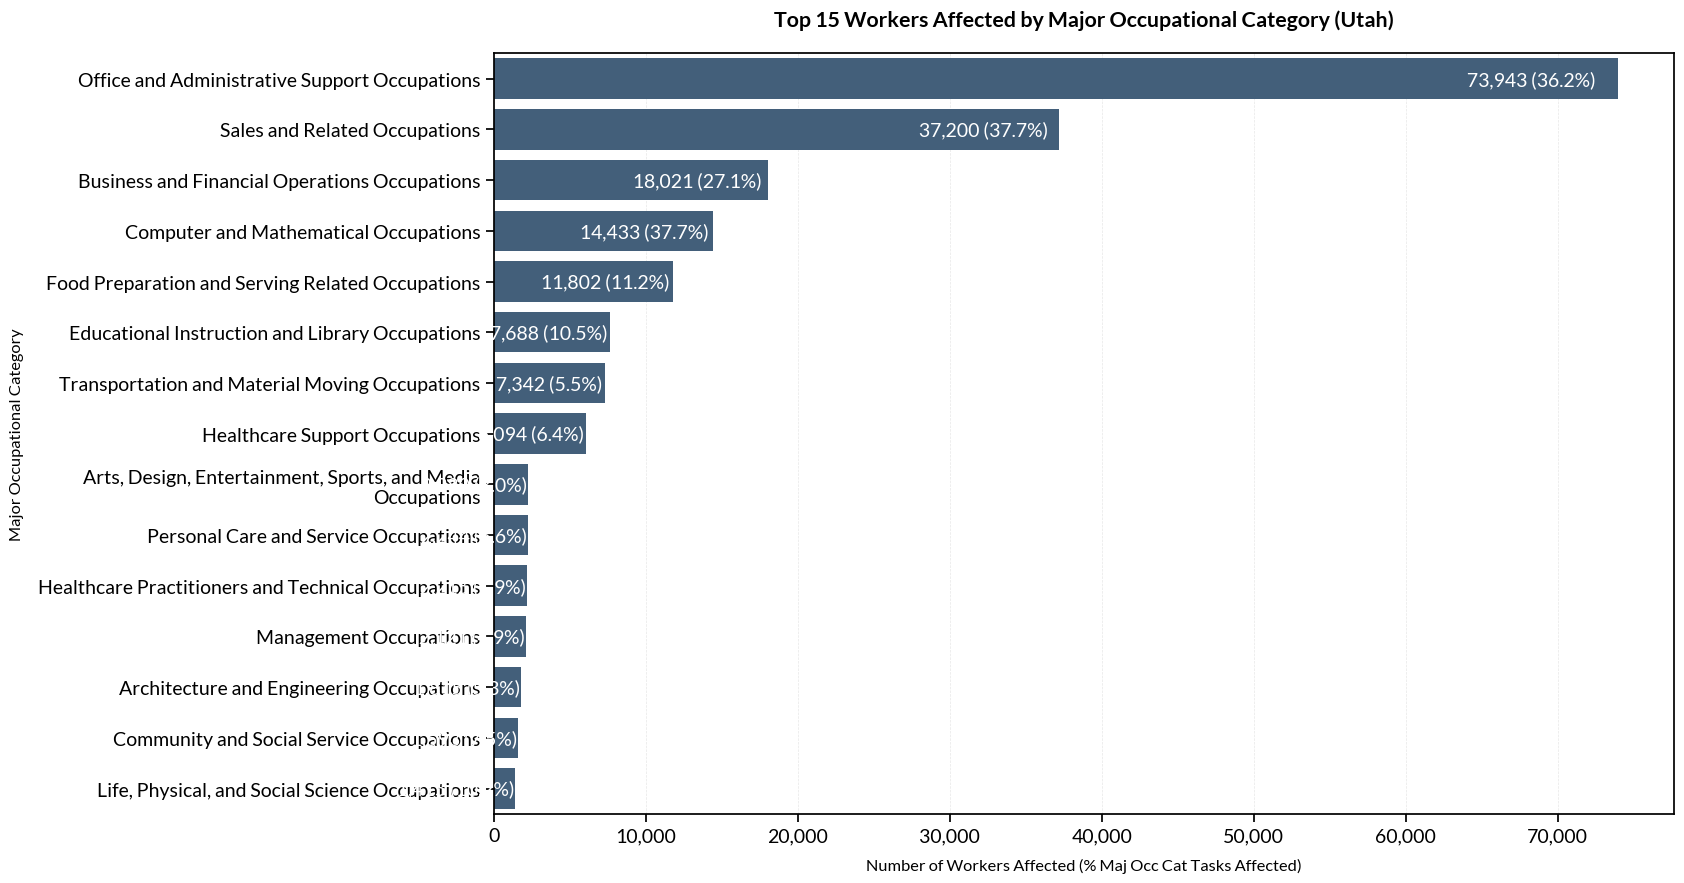

Saved: 01b_Workers_by_Occ_Category_Utah_max_ge_5.png


In [8]:
grouped = (
    df_clean.groupby("major_occ_category")
    .agg(people_automated_ut=("people_automated_ut", "sum"),
         ai_task_comp_ut     =("ai_task_comp_ut",     "sum"),
         task_comp_ut        =("task_comp_ut",        "sum"))
    .assign(pct=lambda x: x.ai_task_comp_ut / x.task_comp_ut * 100)
    .sort_values("people_automated_ut", ascending=False)
    .head(TOP_N_CATEGORIES)
    .reset_index()
)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=grouped, x="people_automated_ut", y="major_occ_category",
            color=MAIN_COLOR, ax=ax)

for i, row in grouped.iterrows():
    ax.text(row.people_automated_ut * 0.98, i,
            f' {row.people_automated_ut:,.0f} ({row.pct:.1f}%)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)
plt.subplots_adjust(left=0.38)
ax.set_title(f"Top {TOP_N_CATEGORIES} Workers Affected by Major Occupational Category (Utah)",
             fontsize=FONT_SIZE * 1.1, fontweight='bold', pad=20)
ax.set_xlabel("Number of Workers Affected (% Maj Occ Cat Tasks Affected)",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Major Occupational Category", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"01b_Workers_by_Occ_Category_Utah_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 1c. Top N Most Affected Occupations (National)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\349457670.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 55)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE - 3)


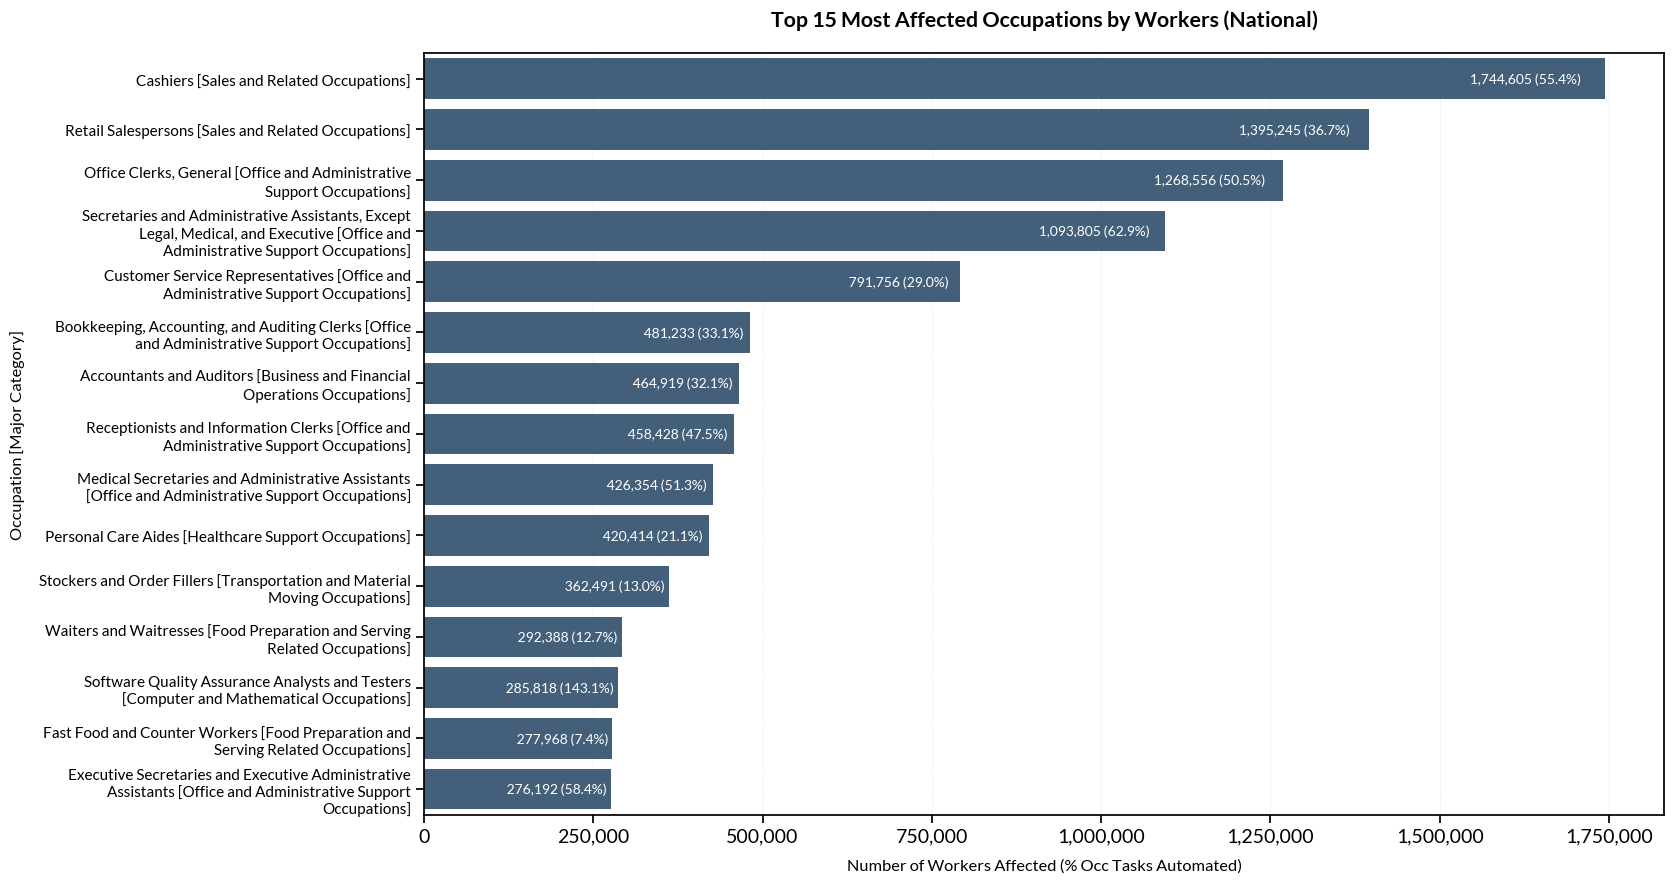

Saved: 01c_Top_Occupations_National_max_ge_5.png


In [9]:
top_n = df_clean.nlargest(TOP_N_OCCUPATIONS, 'people_automated_nat').copy()
top_n['label'] = top_n.apply(lambda r: f"{r['title']} [{r['major_occ_category']}]", axis=1)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=top_n, x='people_automated_nat', y='label', color=MAIN_COLOR, ax=ax)

for i, row in top_n.iterrows():
    ax.text(row.people_automated_nat * 0.98, list(top_n.index).index(i),
            f' {row.people_automated_nat:,.0f} ({row.pct_automated_nat:.1f}%)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE - 4)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 55)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE - 3)
plt.subplots_adjust(left=0.45)
ax.set_title(f"Top {TOP_N_OCCUPATIONS} Most Affected Occupations by Workers (National)",
             fontsize=FONT_SIZE * 1.1, fontweight='bold', pad=20)
ax.set_xlabel("Number of Workers Affected (% Occ Tasks Automated)",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Occupation [Major Category]", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"01c_Top_Occupations_National_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 1d. Top N Most Affected Occupations (Utah)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\1787607439.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 55)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE - 3)


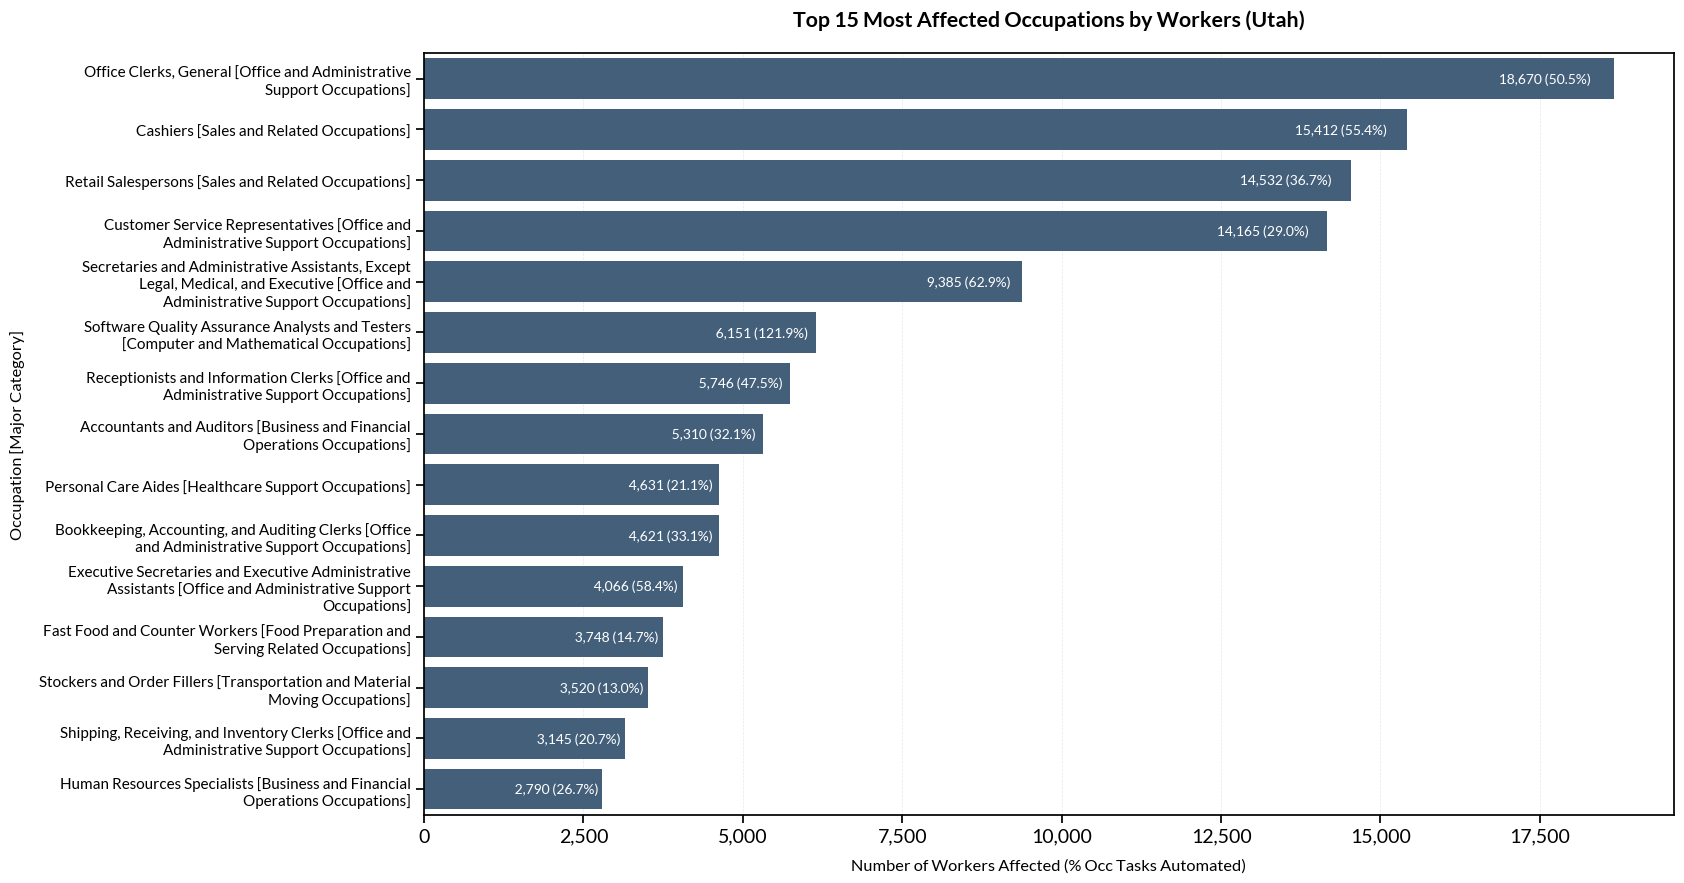

Saved: 01d_Top_Occupations_Utah_max_ge_5.png


In [10]:
top_n = df_clean.nlargest(TOP_N_OCCUPATIONS, 'people_automated_ut').copy()
top_n['label'] = top_n.apply(lambda r: f"{r['title']} [{r['major_occ_category']}]", axis=1)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=top_n, x='people_automated_ut', y='label', color=MAIN_COLOR, ax=ax)

for i, row in top_n.iterrows():
    ax.text(row.people_automated_ut * 0.98, list(top_n.index).index(i),
            f' {row.people_automated_ut:,.0f} ({row.pct_automated_ut:.1f}%)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE - 4)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 55)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE - 3)
plt.subplots_adjust(left=0.45)
ax.set_title(f"Top {TOP_N_OCCUPATIONS} Most Affected Occupations by Workers (Utah)",
             fontsize=FONT_SIZE * 1.1, fontweight='bold', pad=20)
ax.set_xlabel("Number of Workers Affected (% Occ Tasks Automated)",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Occupation [Major Category]", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"01d_Top_Occupations_Utah_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 1e. Wages Generated by Major Occupational Category (National)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\1994389825.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)


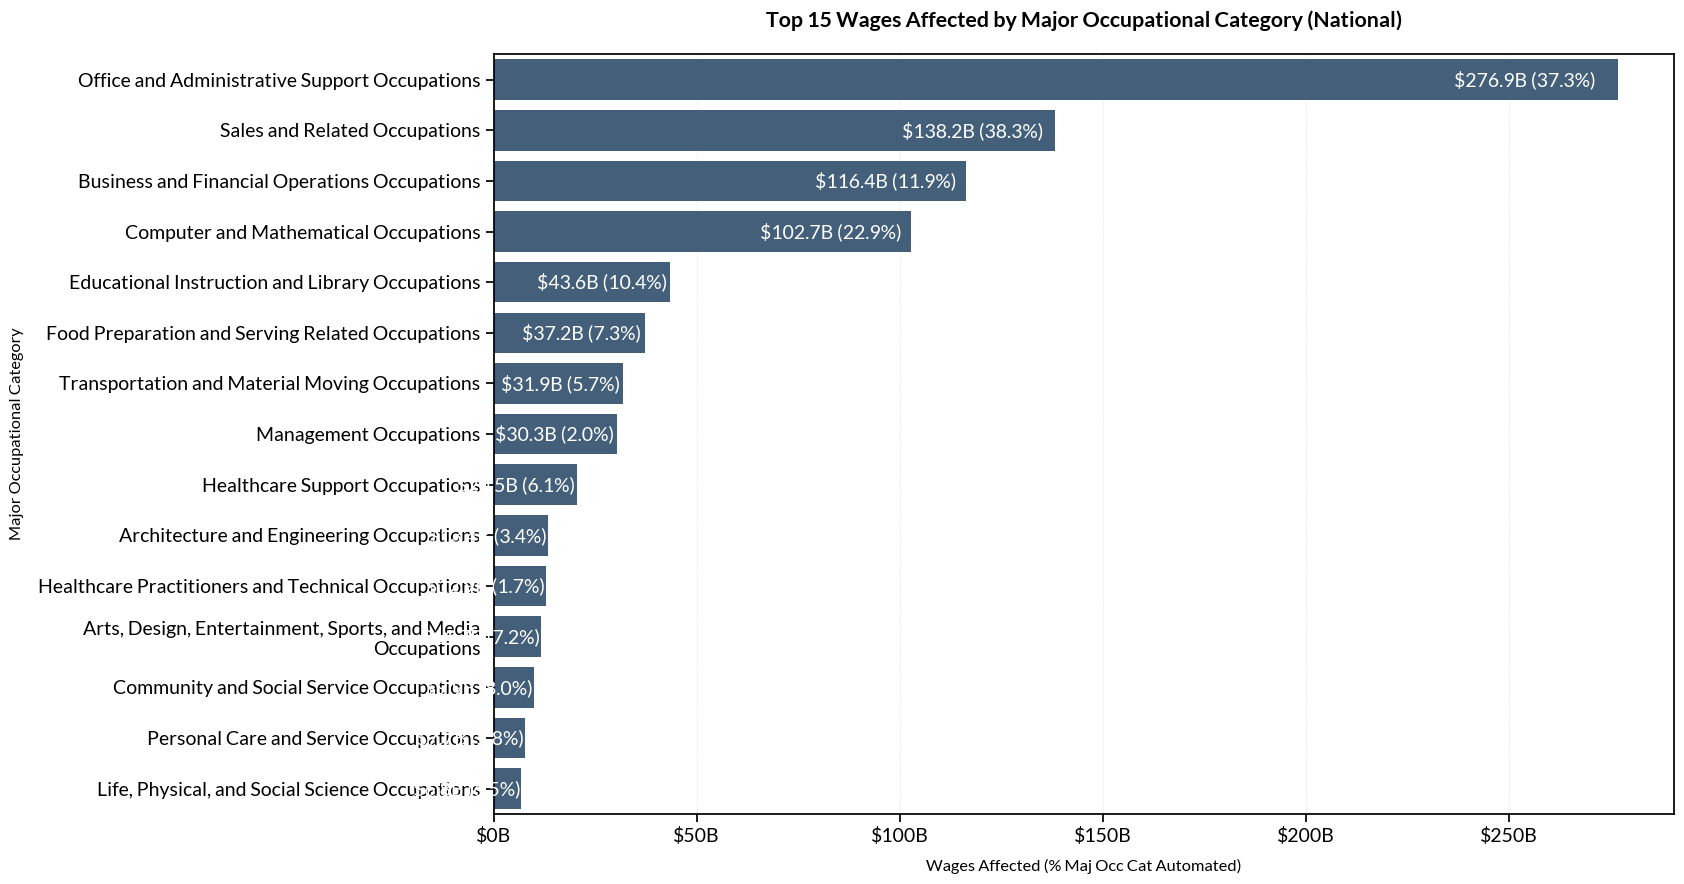

Saved: 01e_Wages_by_Occ_Category_National_max_ge_5.png


In [11]:
grouped = (
    df_clean.groupby("major_occ_category")
    .agg(eco_value_nat =("eco_value_nat",     "sum"),
         ai_task_comp_nat=("ai_task_comp_nat", "sum"),
         task_comp_nat  =("task_comp_nat",     "sum"))
    .assign(pct=lambda x: x.ai_task_comp_nat / x.task_comp_nat * 100)
    .sort_values("eco_value_nat", ascending=False)
    .head(TOP_N_CATEGORIES)
    .reset_index()
)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=grouped, x='eco_value_nat', y='major_occ_category', color=MAIN_COLOR, ax=ax)

for i, row in grouped.iterrows():
    ax.text(row.eco_value_nat * 0.98, i,
            f'${row.eco_value_nat/1e9:,.1f}B ({row.pct:.1f}%)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)
plt.subplots_adjust(left=0.38)
ax.set_title(f"Top {TOP_N_CATEGORIES} Wages Affected by Major Occupational Category (National)",
             fontsize=FONT_SIZE * 1.1, fontweight='bold', pad=20)
ax.set_xlabel("Wages Affected (% Maj Occ Cat Automated)",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Major Occupational Category", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e9:,.0f}B"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"01e_Wages_by_Occ_Category_National_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 1f. Wages Generated by Major Occupational Category (Utah)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\1030400620.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)


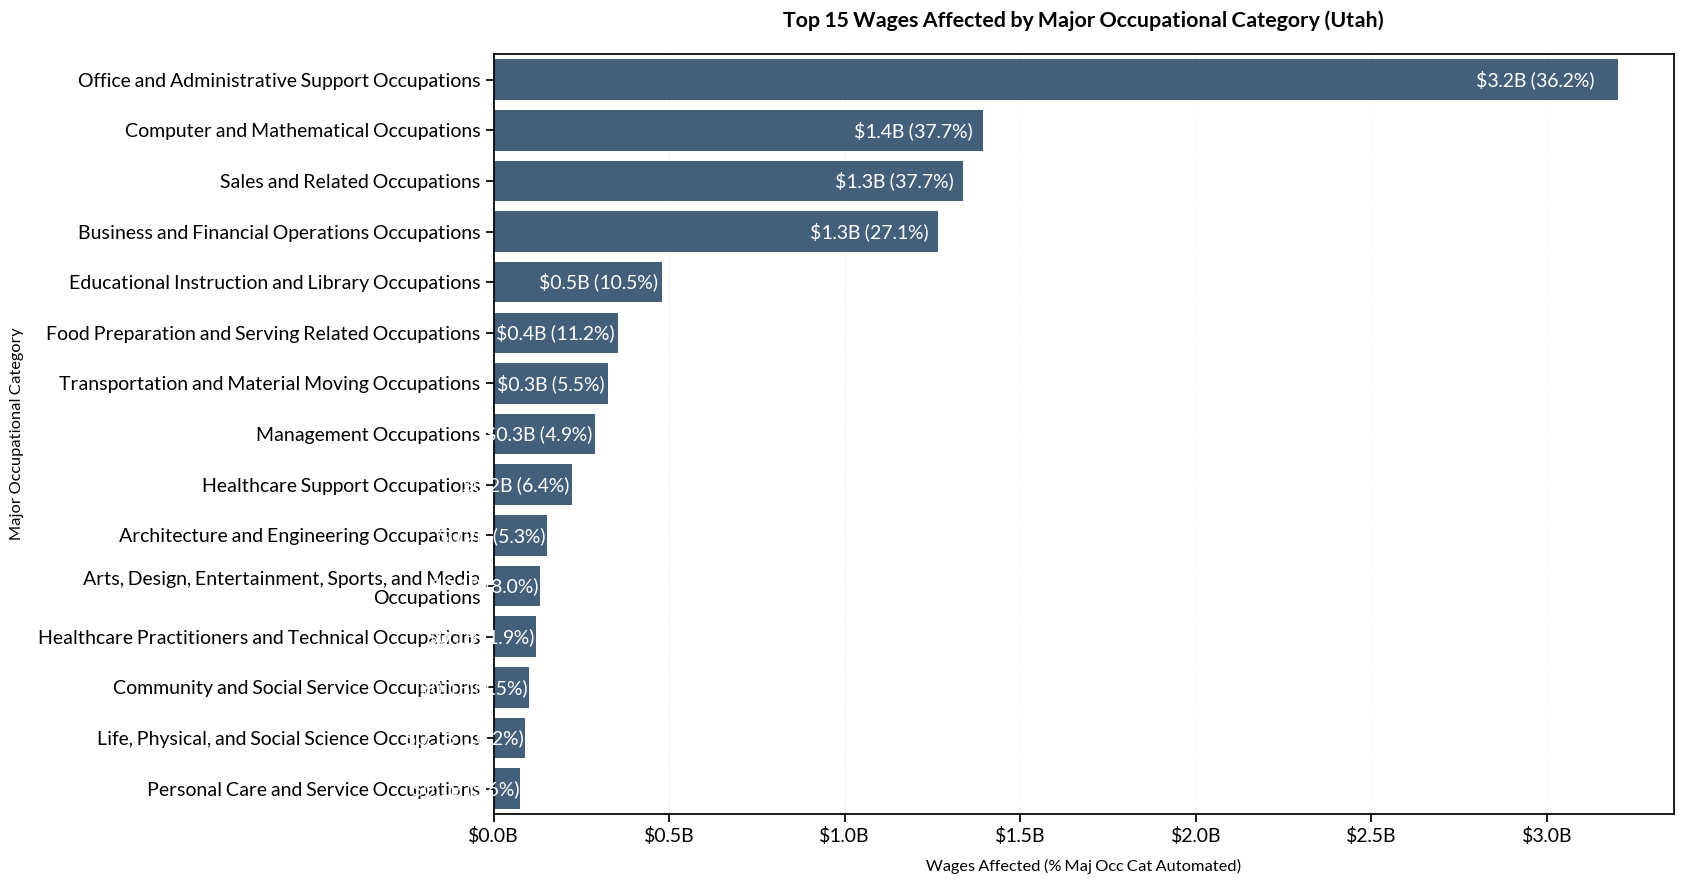

Saved: 01f_Wages_by_Occ_Category_Utah_max_ge_5.png


In [12]:
grouped = (
    df_clean.groupby("major_occ_category")
    .agg(eco_value_ut  =("eco_value_ut",       "sum"),
         ai_task_comp_ut=("ai_task_comp_ut",   "sum"),
         task_comp_ut   =("task_comp_ut",       "sum"))
    .assign(pct=lambda x: x.ai_task_comp_ut / x.task_comp_ut * 100)
    .sort_values("eco_value_ut", ascending=False)
    .head(TOP_N_CATEGORIES)
    .reset_index()
)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=grouped, x='eco_value_ut', y='major_occ_category', color=MAIN_COLOR, ax=ax)

for i, row in grouped.iterrows():
    ax.text(row.eco_value_ut * 0.98, i,
            f'${row.eco_value_ut/1e9:,.1f}B ({row.pct:.1f}%)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE)
plt.subplots_adjust(left=0.38)
ax.set_title(f"Top {TOP_N_CATEGORIES} Wages Affected by Major Occupational Category (Utah)",
             fontsize=FONT_SIZE * 1.1, fontweight='bold', pad=20)
ax.set_xlabel("Wages Affected (% Maj Occ Cat Automated)",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Major Occupational Category", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e9:,.1f}B"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"01f_Wages_by_Occ_Category_Utah_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

---
# Section 2: Variant Comparison Matrix

Compares all 12 scoring variants against the default (`max_ge_4`) to show how sensitive results are to the scoring approach.

In [13]:
def aggregate_variant(df):
    """Aggregate occupation-level df to major category totals."""
    d = df[df["freq_sum_ai"] <= df["freq_sum_eco"]].copy()
    g = d.groupby("major_occ_category").agg(
        people_nat=("people_automated_nat", "sum"),
        eco_nat   =("eco_value_nat",        "sum"),
        people_ut =("people_automated_ut",  "sum"),
        eco_ut    =("eco_value_ut",         "sum"),
        ai_comp   =("ai_task_comp_nat",     "sum"),
        tot_comp  =("task_comp_nat",        "sum"),
    ).reset_index()
    g["pct_nat"] = g.ai_comp / g.tot_comp * 100
    return g

# Load baseline (DEFAULT_VARIANT)
base_agg = aggregate_variant(df_clean).rename(columns={
    "people_nat": "base_people_nat", "eco_nat": "base_eco_nat",
    "people_ut":  "base_people_ut",  "eco_ut":  "base_eco_ut",
    "pct_nat":    "base_pct_nat"
})

# Load all variants
variant_files = sorted(glob(os.path.join(MCP_VARIATIONS_DIR, "automation_mcp_*.csv")))
variant_results = []

for vf in variant_files:
    vname = os.path.basename(vf).replace("automation_mcp_", "").replace(".csv", "")
    vdf = pd.read_csv(vf)
    vagg = aggregate_variant(vdf)
    comp = base_agg.merge(vagg, on="major_occ_category", how="outer")
    comp["variant"] = vname
    comp["Δ workers (nat)"]   = comp["people_nat"] - comp["base_people_nat"]
    comp["Δ wages (nat)"]     = comp["eco_nat"]    - comp["base_eco_nat"]
    comp["Δ workers (ut)"]    = comp["people_ut"]  - comp["base_people_ut"]
    comp["% Δ workers (nat)"] = comp["Δ workers (nat)"] / comp["base_people_nat"] * 100
    comp["% Δ wages (nat)"]   = comp["Δ wages (nat)"]   / comp["base_eco_nat"]    * 100
    comp["% Δ workers (ut)"]  = comp["Δ workers (ut)"]  / comp["base_people_ut"]  * 100
    variant_results.append(comp)

comparison_df = pd.concat(variant_results, ignore_index=True)
print(f"Loaded {len(variant_files)} variants for comparison")

# Pivot to wide format: rows = categories, cols = variant × metric
pivot = (
    comparison_df
    .set_index(["major_occ_category", "variant"])[["people_nat", "% Δ workers (nat)", "eco_nat", "% Δ wages (nat)"]]
    .unstack(level="variant")
)
pivot.columns = [f"{col[1]} | {col[0]}" for col in pivot.columns]
pivot = pivot.round(1)

# Totals row
variant_totals = (
    comparison_df.groupby("variant")
    .agg(total_workers_nat=("people_nat", "sum"),
         total_wages_nat  =("eco_nat",    "sum"),
         total_workers_ut =("people_ut",  "sum"))
    .reset_index()
    .sort_values("total_workers_nat", ascending=False)
)
variant_totals["total_wages_B"] = variant_totals["total_wages_nat"] / 1e9
print("\nAll variants — national totals:")
display(variant_totals[["variant", "total_workers_nat", "total_wages_B", "total_workers_ut"]]
        .rename(columns={"total_workers_nat": "Workers (Nat)",
                         "total_wages_B": "Wages $B (Nat)",
                         "total_workers_ut": "Workers (UT)"})
        .style.format({"Workers (Nat)": "{:,.0f}",
                       "Wages $B (Nat)": "${:.1f}B",
                       "Workers (UT)": "{:,.0f}"}))

Loaded 12 variants for comparison

All variants — national totals:


,variant,Workers (Nat),Wages $B (Nat),Workers (UT)
0,max_ge_1,"88,053,212",$5470.5B,"1,002,906"
6,mean_ge_1,"88,053,212",$5470.5B,"1,002,906"
1,max_ge_2,"77,578,882",$4903.4B,"882,982"
2,max_ge_3,"62,249,837",$3959.1B,"716,521"
5,max_weighted,"57,770,026",$3566.2B,"660,738"
7,mean_ge_2,"45,630,981",$2792.7B,"525,081"
3,max_ge_4,"43,984,464",$2617.2B,"506,919"
11,mean_weighted,"35,885,359",$2207.2B,"408,960"
4,max_ge_5,"16,983,736",$880.8B,"194,362"
8,mean_ge_3,"12,253,746",$704.6B,"136,079"


### 2a. Variant Totals Bar Chart

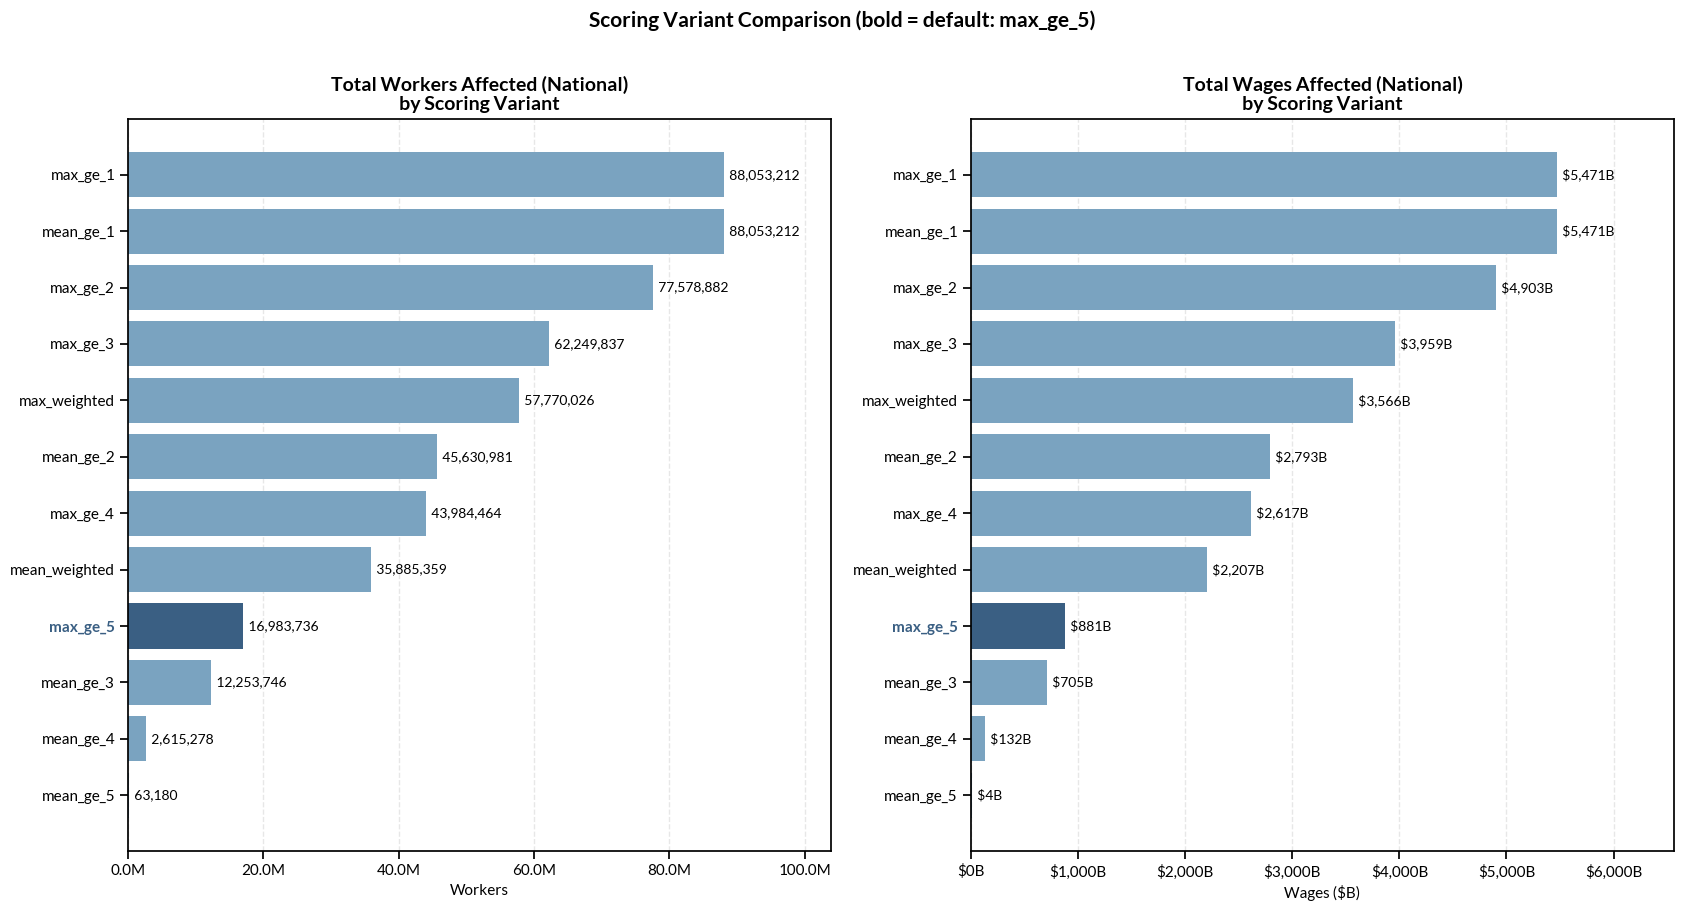

Saved: 02a_Variant_Totals_Comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=CHART_SIZE)

vt = variant_totals.sort_values("total_workers_nat")

# Workers
colors = [MAIN_COLOR if v == DEFAULT_VARIANT else "#7aa3c0" for v in vt["variant"]]
axes[0].barh(vt["variant"], vt["total_workers_nat"], color=colors)
for i, (_, row) in enumerate(vt.iterrows()):
    axes[0].text(row.total_workers_nat, i, f'  {row.total_workers_nat:,.0f}',
                 va='center', ha='left', fontsize=10)
axes[0].set_title("Total Workers Affected (National)\nby Scoring Variant",
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel("Workers", fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].set_xlim(right=vt.total_workers_nat.max() * 1.18)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# Wages
axes[1].barh(vt["variant"], vt["total_wages_B"], color=colors)
for i, (_, row) in enumerate(vt.iterrows()):
    axes[1].text(row.total_wages_B, i, f'  ${row.total_wages_B:,.0f}B',
                 va='center', ha='left', fontsize=10)
axes[1].set_title("Total Wages Affected (National)\nby Scoring Variant",
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel("Wages ($B)", fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
axes[1].set_xlim(right=vt.total_wages_B.max() * 1.2)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

# Highlight default variant label
for ax in axes:
    labels = [t.get_text() for t in ax.get_yticklabels()]
    for tick, lbl in zip(ax.get_yticklabels(), labels):
        if lbl == DEFAULT_VARIANT:
            tick.set_fontweight('bold')
            tick.set_color(MAIN_COLOR)

plt.suptitle(f"Scoring Variant Comparison (bold = default: {DEFAULT_VARIANT})",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

fname = "02a_Variant_Totals_Comparison.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 2b. Styled Variant × Category Comparison Table

In [15]:
# Summary table: workers and % change for each variant × category
summary = (
    comparison_df
    .pivot_table(index="major_occ_category",
                 columns="variant",
                 values=["people_nat", "% Δ workers (nat)"],
                 aggfunc="sum")
)

# Flatten columns
summary.columns = [f"{v} | {m}" for m, v in summary.columns]
summary = summary.round(1)

pct_cols   = [c for c in summary.columns if "% Δ" in c]
count_cols = [c for c in summary.columns if "people" in c]

def red_grad(series):
    mx = series.abs().max()
    return [f"background-color: rgba(220,53,69,{0.15+0.6*(abs(v)/mx if mx else 0)})"
            if not pd.isna(v) else "" for v in series]

def blue_grad(series):
    mx = series.abs().max()
    return [f"background-color: rgba(0,123,255,{0.10+0.5*(abs(v)/mx if mx else 0)})"
            if not pd.isna(v) else "" for v in series]

styled = (
    summary.style
    .format(precision=1, thousands=",")
    .apply(red_grad,  subset=pct_cols,   axis=0)
    .apply(blue_grad, subset=count_cols, axis=0)
    .set_caption(f"MCP Variant Comparison — Workers by Category (vs baseline: {DEFAULT_VARIANT})")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","15px"),("font-weight","bold"),("text-align","center")]},
        {"selector": "th",
         "props": [("background-color","#f2f2f2"),("font-weight","bold"),("font-size","11px")]},
    ])
)
display(styled)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\234374751.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return [f"background-color: rgba(220,53,69,{0.15+0.6*(abs(v)/mx if mx else 0)})"


,max_ge_1 | % Δ workers (nat),max_ge_2 | % Δ workers (nat),max_ge_3 | % Δ workers (nat),max_ge_4 | % Δ workers (nat),max_ge_5 | % Δ workers (nat),max_weighted | % Δ workers (nat),mean_ge_1 | % Δ workers (nat),mean_ge_2 | % Δ workers (nat),mean_ge_3 | % Δ workers (nat),mean_ge_4 | % Δ workers (nat),mean_ge_5 | % Δ workers (nat),mean_weighted | % Δ workers (nat),max_ge_1 | people_nat,max_ge_2 | people_nat,max_ge_3 | people_nat,max_ge_4 | people_nat,max_ge_5 | people_nat,max_weighted | people_nat,mean_ge_1 | people_nat,mean_ge_2 | people_nat,mean_ge_3 | people_nat,mean_ge_4 | people_nat,mean_ge_5 | people_nat,mean_weighted | people_nat
major_occ_category,,,,,,,,,,,,,,,,,,,,,,,,
Architecture and Engineering Occupations,"1,037.8",941.4,727.9,295.5,0.0,600.5,"1,037.8",263.3,-73.1,-100.0,-100.0,293.1,"1,651,471.7","1,511,580.3","1,201,614.8","574,031.8","145,146.9","1,016,769.1","1,651,471.7","527,329.7","39,102.4",0.0,0.0,"570,547.4"
"Arts, Design, Entertainment, Sports, and Media Occupations",859.5,780.4,535.0,280.5,0.0,491.1,859.5,319.5,-11.6,-98.0,-100.0,271.3,"1,691,661.8","1,552,278.3","1,119,616.9","670,826.6","176,308.4","1,042,138.4","1,691,661.8","739,635.2","155,800.2","3,464.3",0.0,"654,702.7"
Building and Grounds Cleaning and Maintenance Occupations,"3,007.8","1,265.9",815.6,358.5,0.0,"1,089.5","3,007.8","1,087.9",373.6,-75.3,-100.0,895.9,"1,654,055.9","726,934.0","487,292.4","243,996.3","53,221.9","633,100.1","1,654,055.9","632,200.5","252,064.6","13,121.4",0.0,"530,039.6"
Business and Financial Operations Occupations,389.9,355.6,244.7,155.8,0.0,229.2,389.9,198.3,-27.2,-85.8,-100.0,106.2,"7,250,363.6","6,743,441.3","5,102,023.6","3,786,224.0","1,480,036.5","4,872,417.8","7,250,363.6","4,415,375.6","1,077,478.1","210,903.2",183.9,"3,052,509.9"
Community and Social Service Occupations,825.2,616.9,392.2,107.6,0.0,388.4,825.2,286.6,-18.2,-92.7,-100.0,233.2,"1,553,125.4","1,203,392.7","826,277.4","348,482.9","167,867.8","819,829.2","1,553,125.4","648,934.1","137,337.4","12,276.9",0.0,"559,378.9"
Computer and Mathematical Occupations,203.7,201.2,192.0,140.2,0.0,147.4,203.7,97.9,-76.8,-100.0,-100.0,34.8,"3,163,178.6","3,136,809.1","3,041,194.0","2,501,883.1","1,041,461.1","2,576,905.2","3,163,178.6","2,061,487.6","241,938.3",0.0,0.0,"1,403,820.3"
Construction and Extraction Occupations,"2,147.2","1,238.1",804.0,218.7,0.0,881.6,"2,147.2",552.1,96.4,-100.0,-100.0,601.3,"1,839,264.7","1,095,235.5","739,915.3","260,817.3","81,848.0","803,416.2","1,839,264.7","533,715.2","160,788.7",0.0,0.0,"574,010.2"
Educational Instruction and Library Occupations,448.9,425.9,260.2,140.4,0.0,255.1,448.9,188.0,23.7,-81.3,-100.0,135.9,"3,939,709.5","3,774,140.7","2,585,534.4","1,725,152.6","717,705.6","2,548,448.6","3,939,709.5","2,067,143.8","887,507.4","133,932.1",0.0,"1,693,232.5"
"Farming, Fishing, and Forestry Occupations",inf,inf,inf,inf,0.0,inf,inf,inf,inf,inf,0.0,inf,"134,860.0","99,167.2","73,561.9","9,292.6",0.0,"63,376.3","134,860.0","85,792.4","37,529.9","1,820.7",0.0,"54,660.6"


---
# Section 3: MCP-Specific Analysis

Deeper dives into the automation landscape that go beyond what the executive summary covers.

### 3a. Automation Rate Distribution by Major Occupational Category

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\1533045602.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=12)


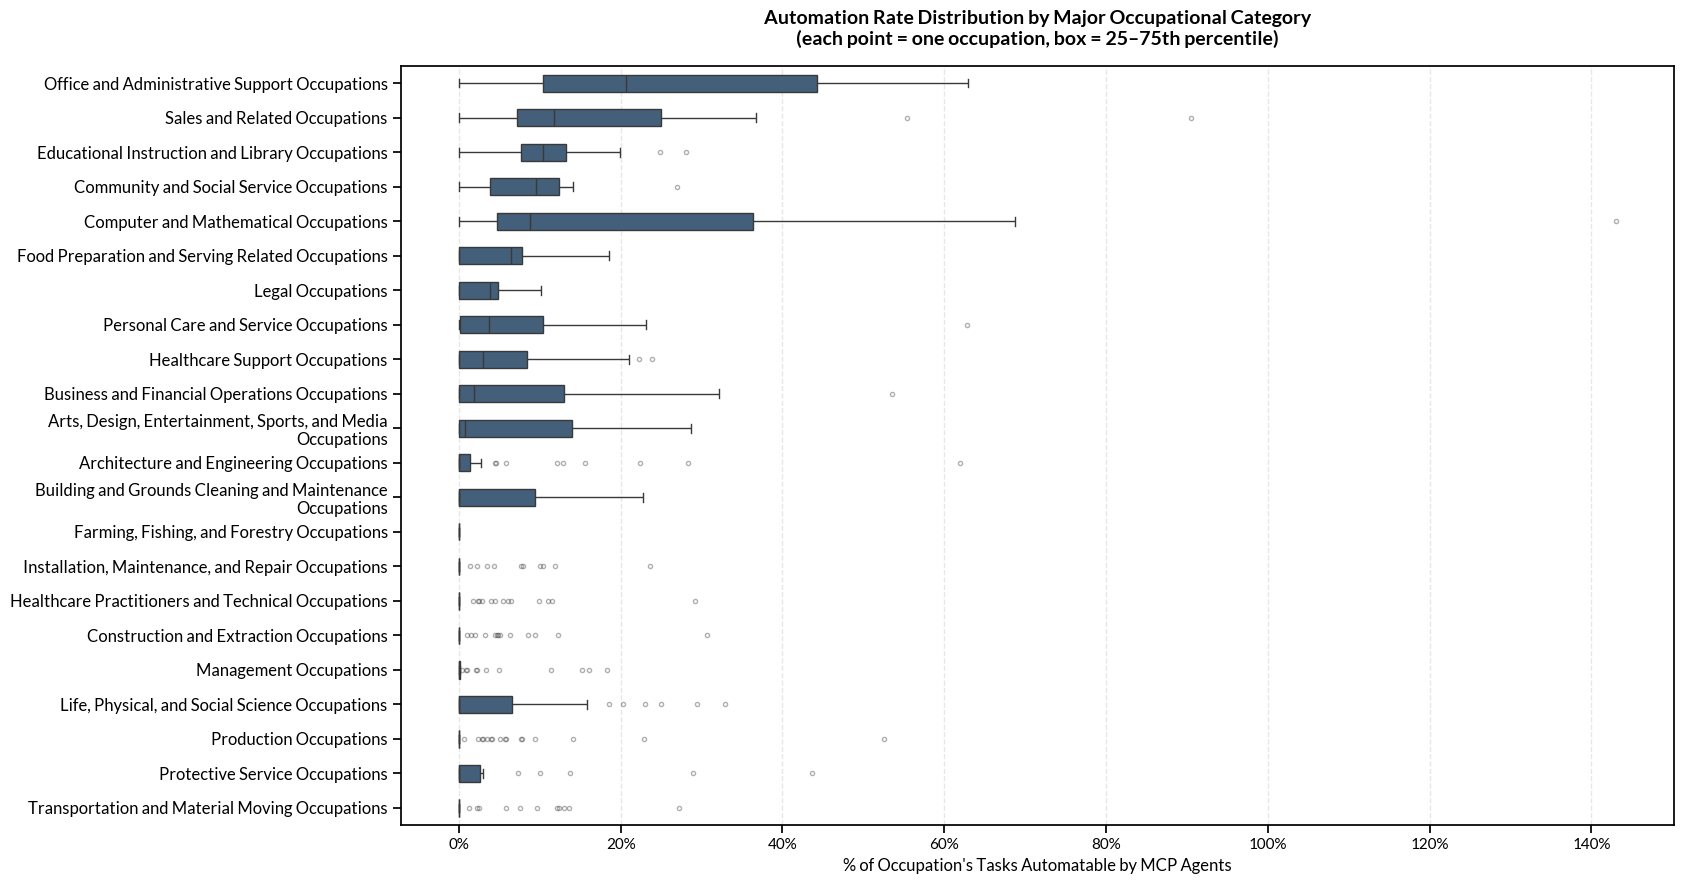

Saved: 03a_Automation_Rate_Distribution_max_ge_5.png


In [16]:
# Box plot of pct_automated_nat across individual occupations within each major category
cat_order = (
    df_clean.groupby("major_occ_category")["pct_automated_nat"]
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.boxplot(data=df_clean, y="major_occ_category", x="pct_automated_nat",
            order=cat_order, color=MAIN_COLOR, width=0.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)

ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=12)
plt.subplots_adjust(left=0.40)
ax.set_title("Automation Rate Distribution by Major Occupational Category\n"
             "(each point = one occupation, box = 25–75th percentile)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("% of Occupation's Tasks Automatable by MCP Agents", fontsize=12)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"03a_Automation_Rate_Distribution_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 3b. Automation Rate vs Median Wage (Are High-Wage Jobs More Exposed?)

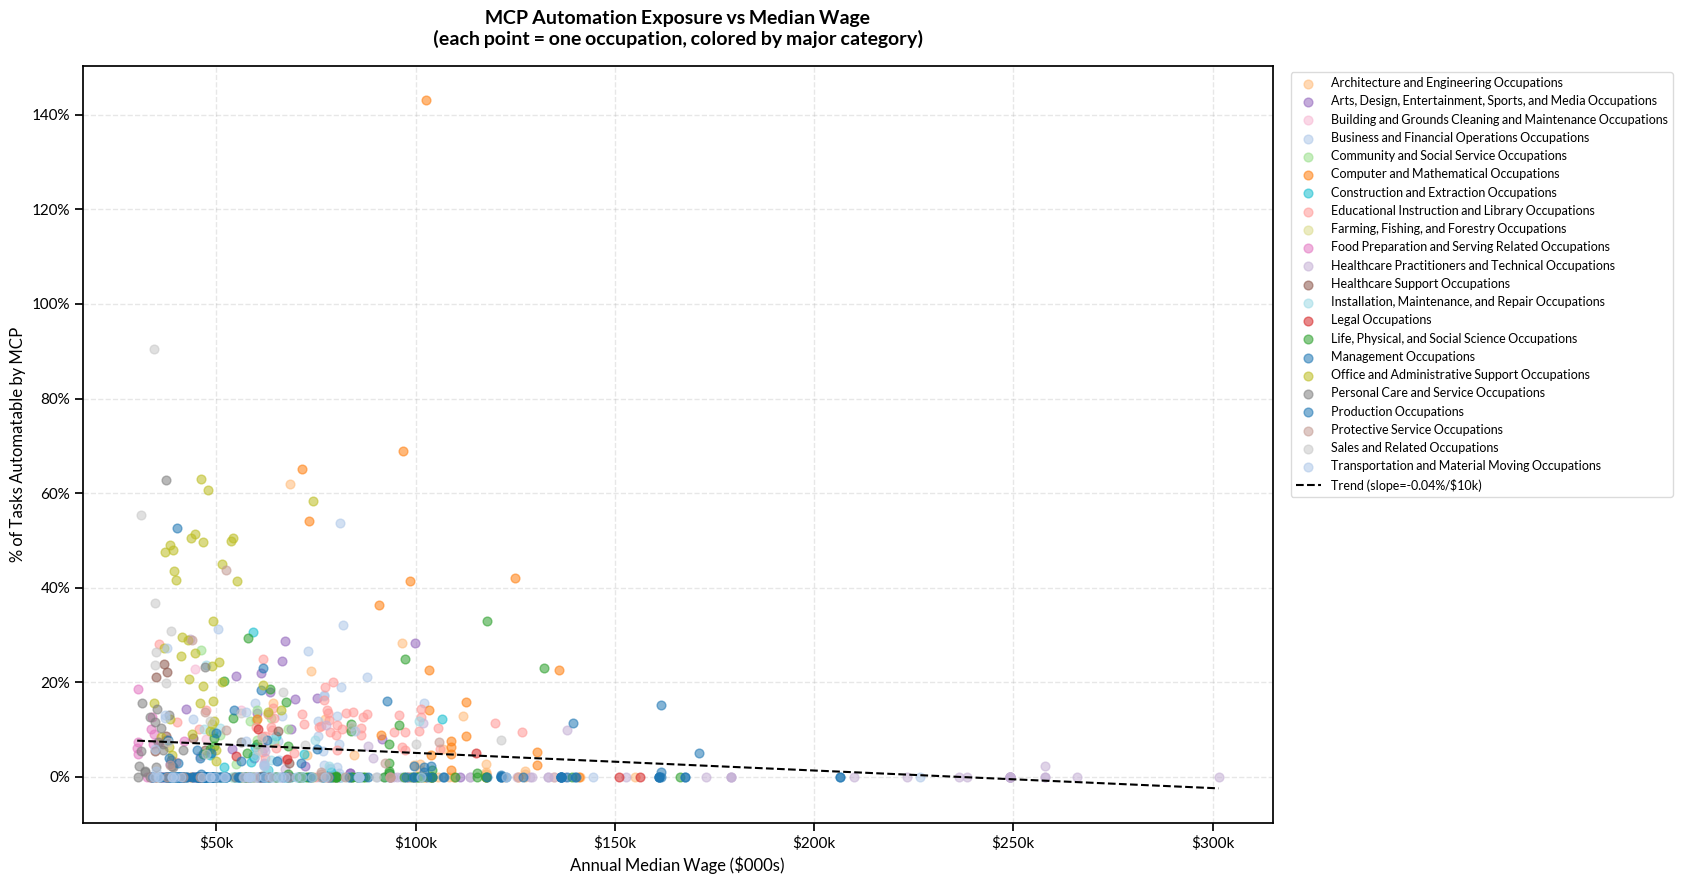

Saved: 03b_Automation_vs_Wage_Scatter_max_ge_5.png
Correlation (wage vs automation %): r = -0.122


In [17]:
plot_df = df_clean.dropna(subset=["a_med_nat", "pct_automated_nat"]).copy()

# Color by major category
categories = plot_df["major_occ_category"].unique()
color_map = dict(zip(categories, sns.color_palette("tab20", len(categories))))

fig, ax = plt.subplots(figsize=CHART_SIZE)

for cat, grp in plot_df.groupby("major_occ_category"):
    ax.scatter(grp["a_med_nat"] / 1000, grp["pct_automated_nat"],
               color=color_map[cat], alpha=0.55, s=40, label=cat)

# Trend line
x = plot_df["a_med_nat"] / 1000
y = plot_df["pct_automated_nat"]
z = np.polyfit(x.dropna(), y[x.notna()], 1)
xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, np.polyval(z, xline), 'k--', linewidth=1.5, label=f"Trend (slope={z[0]:.2f}%/$10k)")

ax.set_xlabel("Annual Median Wage ($000s)", fontsize=12)
ax.set_ylabel("% of Tasks Automatable by MCP", fontsize=12)
ax.set_title("MCP Automation Exposure vs Median Wage\n"
             "(each point = one occupation, colored by major category)",
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}k"))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.7)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"03b_Automation_vs_Wage_Scatter_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
corr = plot_df[["a_med_nat", "pct_automated_nat"]].corr().iloc[0, 1]
print(f"Saved: {fname}")
print(f"Correlation (wage vs automation %): r = {corr:.3f}")

### 3c. Top Occupations by Automation Rate (Not Just Raw Count)

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\350857007.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 55)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE - 3)


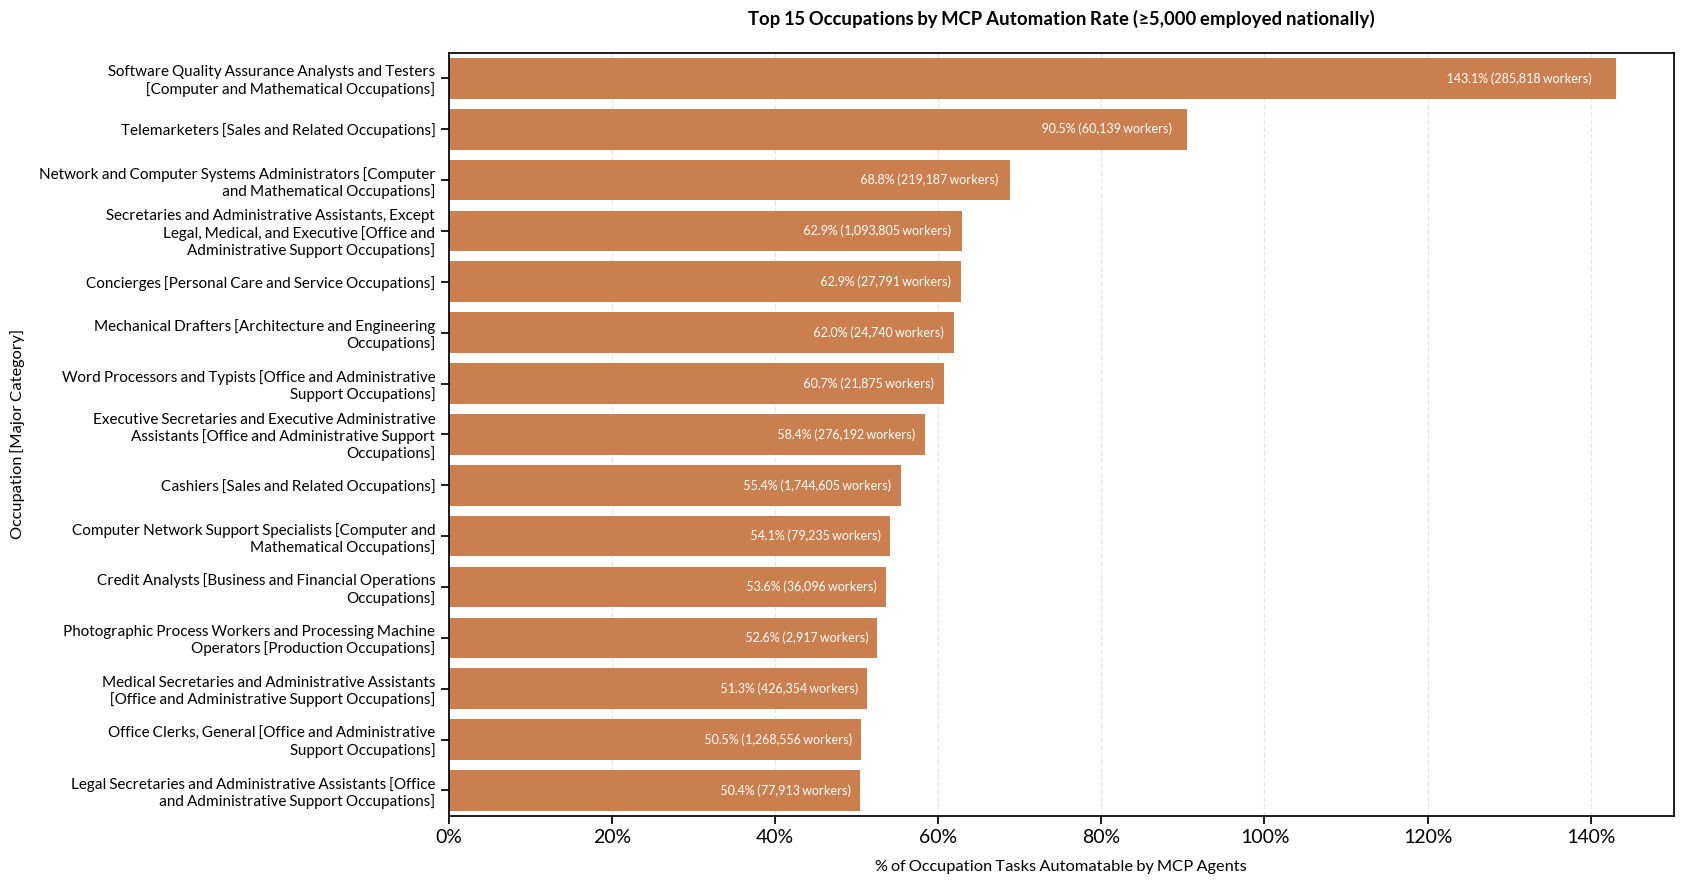

Saved: 03c_Top_Occupations_by_Automation_Rate_max_ge_5.png


In [18]:
# Minimum employment filter so we don't get tiny occupations
MIN_EMP = 5000
high_auto = (
    df_clean[df_clean["tot_emp_nat"] >= MIN_EMP]
    .nlargest(TOP_N_OCCUPATIONS, "pct_automated_nat")
    .copy()
)
high_auto["label"] = high_auto.apply(
    lambda r: f"{r['title']} [{r['major_occ_category']}]", axis=1)

fig, ax = plt.subplots(figsize=CHART_SIZE)
sns.barplot(data=high_auto, x='pct_automated_nat', y='label', color=ACCENT_COLOR, ax=ax)

for i, row in high_auto.reset_index().iterrows():
    ax.text(row.pct_automated_nat * 0.98, i,
            f' {row.pct_automated_nat:.1f}% ({row.people_automated_nat:,.0f} workers)',
            va='center', ha='right', color='white', fontsize=FONT_SIZE - 5)

ax.set_xlim(right=ax.get_xlim()[1] * 1.00)
ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 55)) for t in ax.get_yticklabels()], fontsize=FONT_SIZE - 3)
plt.subplots_adjust(left=0.45)
ax.set_title(f"Top {TOP_N_OCCUPATIONS} Occupations by MCP Automation Rate (≥{MIN_EMP:,} employed nationally)",
             fontsize=FONT_SIZE * 0.95, fontweight='bold', pad=20)
ax.set_xlabel("% of Occupation Tasks Automatable by MCP Agents",
              fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.set_ylabel("Occupation [Major Category]", fontsize=FONT_SIZE * 0.84, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"03c_Top_Occupations_by_Automation_Rate_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 3d. Utah Regional Concentration vs Automation Rate

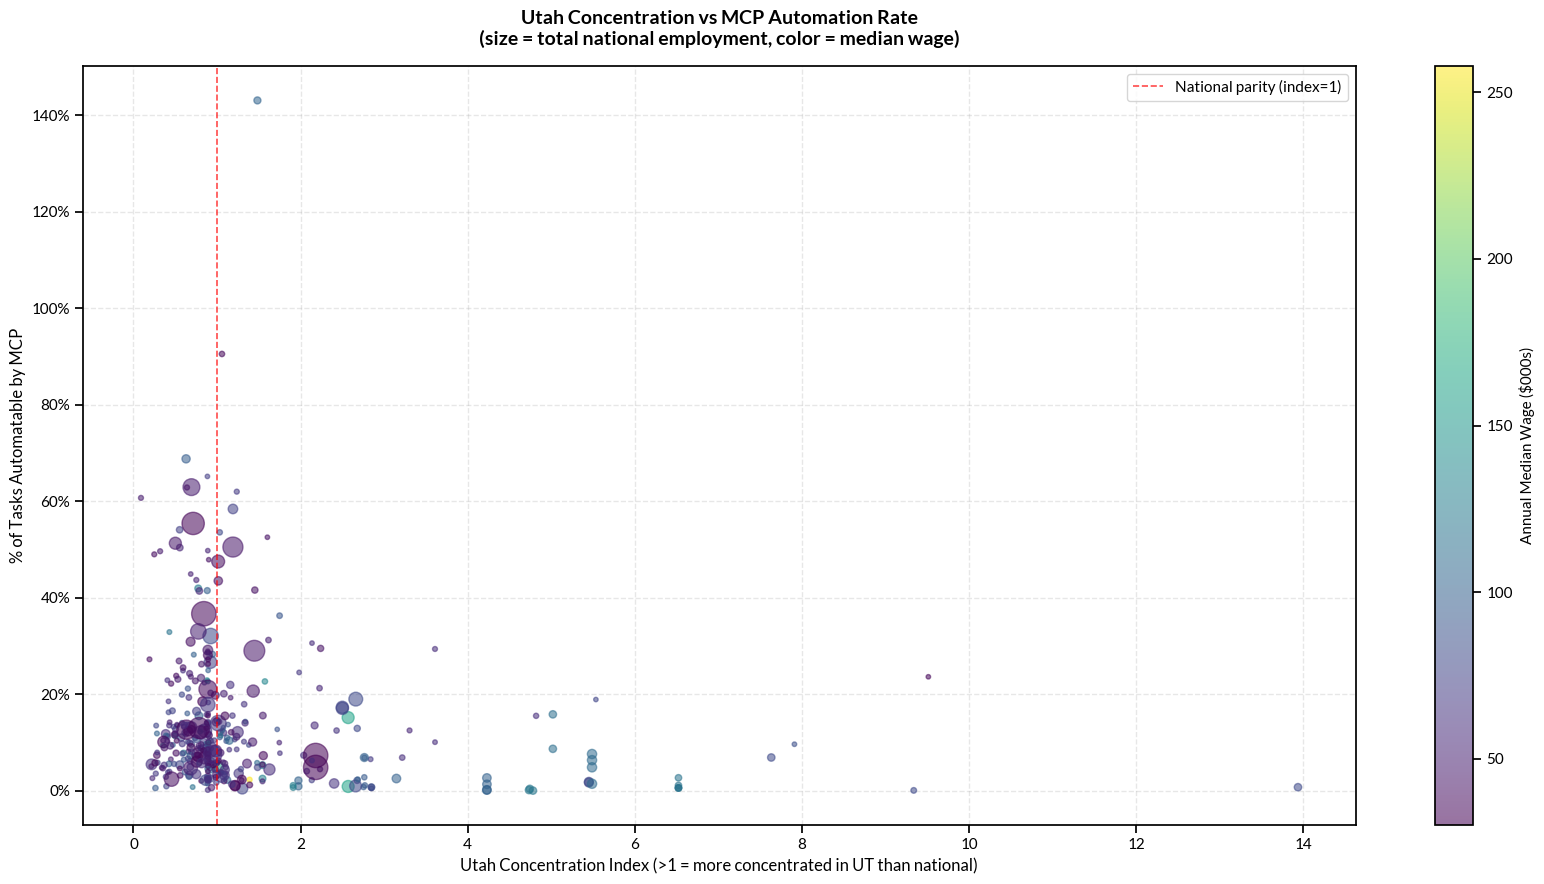

Saved: 03d_Utah_Concentration_vs_Automation_max_ge_5.png

High Utah concentration (>1.2) AND high automation (>50%): 3 occupations


,title,major_occ_category,ut_concentration_index,pct_automated_nat,tot_emp_ut
107,Software Quality Assurance Analysts and Testers,Computer and Mathematical Occupations,1.483486,143.051880,4300.0
164,Mechanical Drafters,Architecture and Engineering Occupations,1.236320,62.003788,610.0
817,Photographic Process Workers and Processing Ma...,Production Occupations,1.602779,52.561350,110.0


In [19]:
# ut_concentration_index > 1 means Utah employs proportionally more of this occupation
plot_df = df_clean.dropna(subset=["ut_concentration_index", "pct_automated_nat"]).copy()
plot_df = plot_df[plot_df["ut_concentration_index"] > 0]

fig, ax = plt.subplots(figsize=CHART_SIZE)

sc = ax.scatter(plot_df["ut_concentration_index"], plot_df["pct_automated_nat"],
                c=plot_df["a_med_nat"] / 1000, cmap="viridis",
                alpha=0.55, s=plot_df["tot_emp_nat"] / plot_df["tot_emp_nat"].max() * 300 + 10)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Annual Median Wage ($000s)", fontsize=11)

ax.axvline(1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label="National parity (index=1)")
ax.set_xlabel("Utah Concentration Index (>1 = more concentrated in UT than national)", fontsize=12)
ax.set_ylabel("% of Tasks Automatable by MCP", fontsize=12)
ax.set_title("Utah Concentration vs MCP Automation Rate\n"
             "(size = total national employment, color = median wage)",
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = f"03d_Utah_Concentration_vs_Automation_{DEFAULT_VARIANT}.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

# Print high-concentration + high-automation occupations
hi_conc_hi_auto = (
    plot_df[(plot_df["ut_concentration_index"] > 1.2) & (plot_df["pct_automated_nat"] > 50)]
    .sort_values("pct_automated_nat", ascending=False)
    [["title", "major_occ_category", "ut_concentration_index", "pct_automated_nat", "tot_emp_ut"]]
)
print(f"\nHigh Utah concentration (>1.2) AND high automation (>50%): {len(hi_conc_hi_auto)} occupations")
display(hi_conc_hi_auto)

---
# Section 4: Task-Level Analysis (MCP Rating Data)

Uses `mcp_tasks_final` which has one row per O*NET task × occupation, with aggregated MCP rating scores.

### 4a. MCP Rating Score Distribution

Tasks with ratings: 11,777
Mean MCP rating: 1.87
Median MCP rating: 1.75
% of tasks with mean_rating >= 3: 9.7%
% of tasks with mean_rating >= 4: 2.1%


C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\628946772.py:34: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Lato.
  plt.tight_layout()
C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\628946772.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Lato.
  plt.tight_layout()
C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\628946772.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Lato.
  plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\628946772.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Lato.
  plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
c:\Users\teddy\Downloads\OAIPR\Technical\automation_exposure_analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Lato.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ted

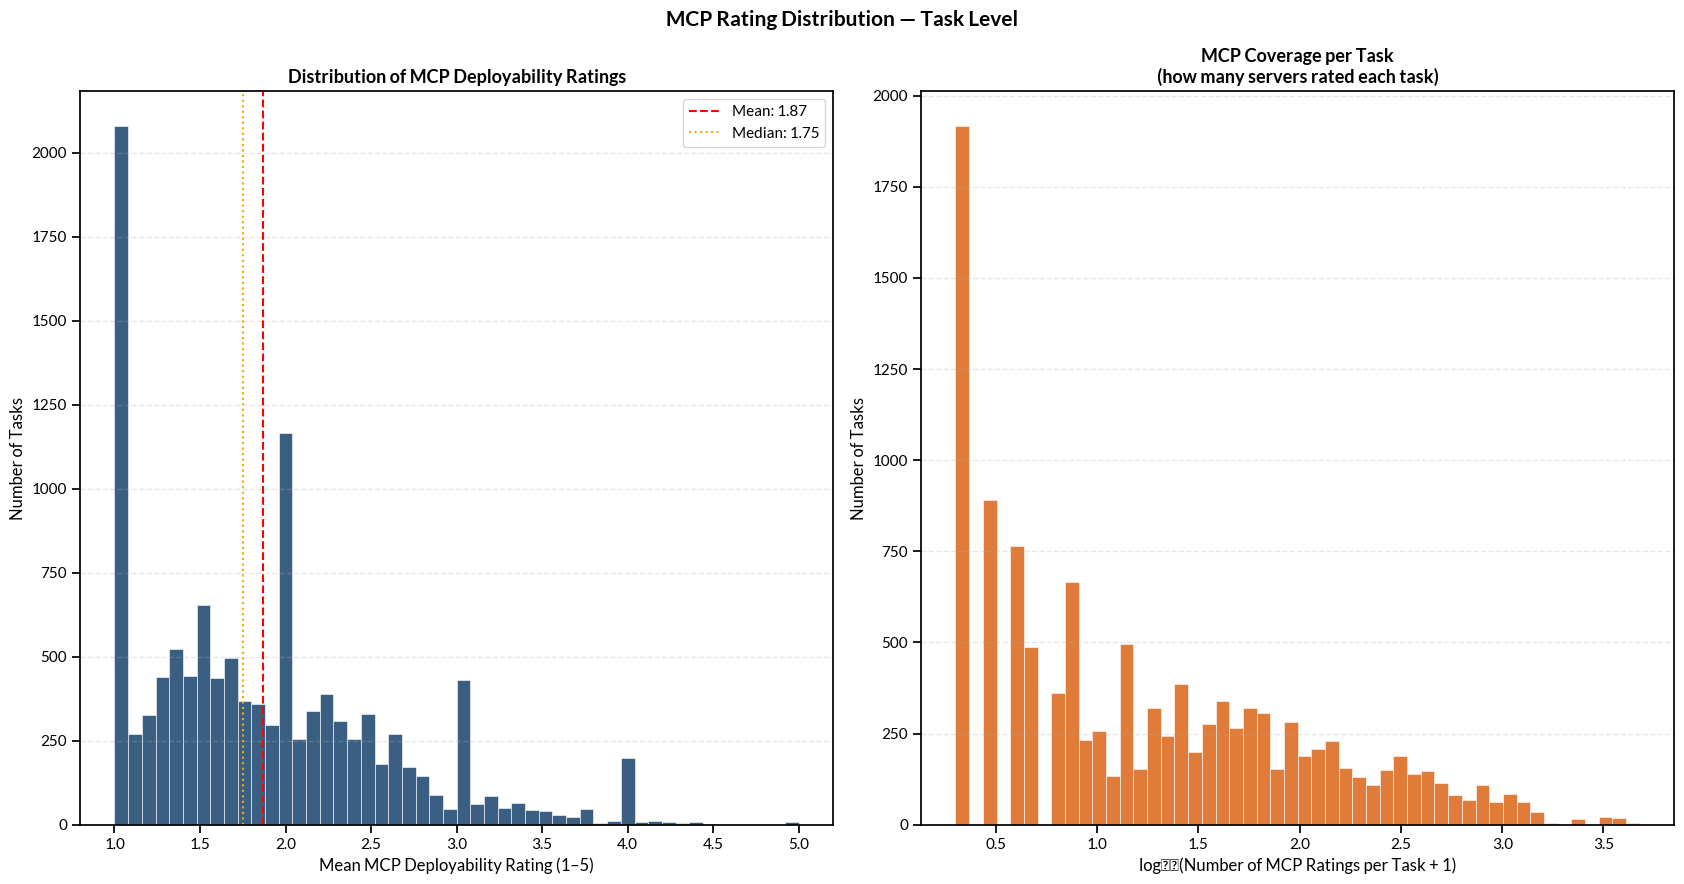

Saved: 04a_MCP_Rating_Distributions.png


In [20]:
rated = tasks_df.dropna(subset=["mean_rating", "n_ratings"]).copy()
rated = rated[rated["n_ratings"] > 0]

print(f"Tasks with ratings: {len(rated):,}")
print(f"Mean MCP rating: {rated['mean_rating'].mean():.2f}")
print(f"Median MCP rating: {rated['mean_rating'].median():.2f}")
print(f"% of tasks with mean_rating >= 3: {(rated['mean_rating'] >= 3).mean()*100:.1f}%")
print(f"% of tasks with mean_rating >= 4: {(rated['mean_rating'] >= 4).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=CHART_SIZE)

# Histogram of mean ratings
axes[0].hist(rated["mean_rating"], bins=50, color=MAIN_COLOR, edgecolor='white', linewidth=0.4)
axes[0].axvline(rated["mean_rating"].mean(), color='red', linestyle='--',
                label=f"Mean: {rated['mean_rating'].mean():.2f}")
axes[0].axvline(rated["mean_rating"].median(), color='orange', linestyle=':',
                label=f"Median: {rated['mean_rating'].median():.2f}")
axes[0].set_xlabel("Mean MCP Deployability Rating (1–5)", fontsize=12)
axes[0].set_ylabel("Number of Tasks", fontsize=12)
axes[0].set_title("Distribution of MCP Deployability Ratings", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# n_ratings distribution (how many MCP servers rated each task)
axes[1].hist(np.log10(rated["n_ratings"] + 1), bins=50,
             color=ACCENT_COLOR, edgecolor='white', linewidth=0.4)
axes[1].set_xlabel("log₁₀(Number of MCP Ratings per Task + 1)", fontsize=12)
axes[1].set_ylabel("Number of Tasks", fontsize=12)
axes[1].set_title("MCP Coverage per Task\n(how many servers rated each task)",
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle("MCP Rating Distribution — Task Level", fontsize=15, fontweight='bold')
plt.tight_layout()

fname = "04a_MCP_Rating_Distributions.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 4b. Mean MCP Rating by Major Occupational Category

C:\Users\teddy\AppData\Local\Temp\ipykernel_57248\2962924421.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=12)


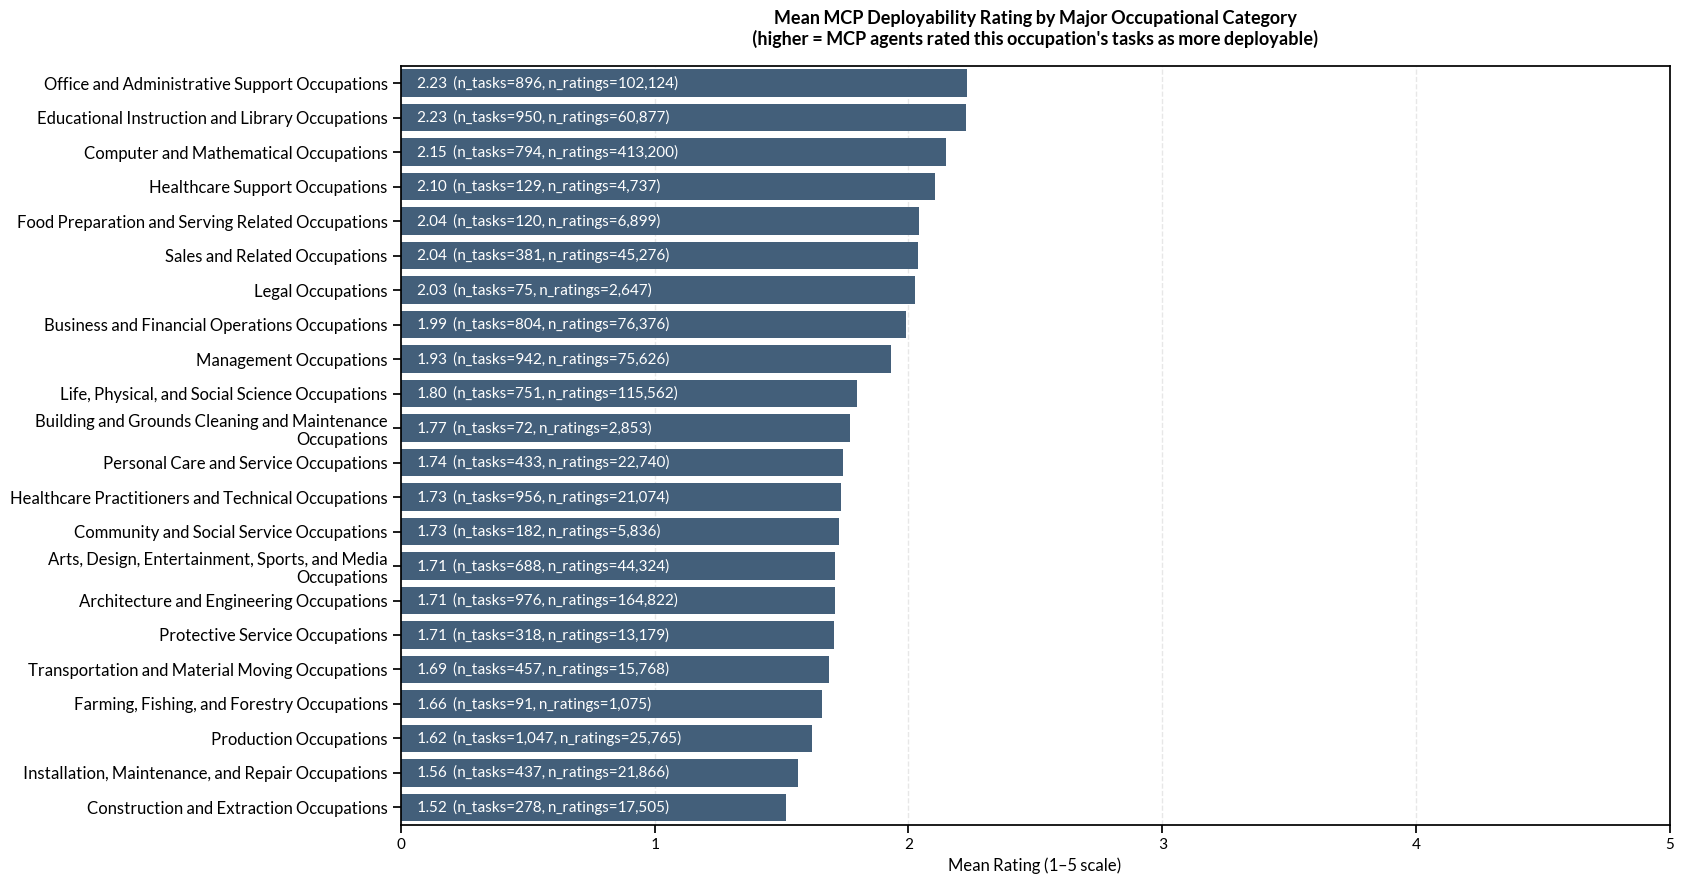

Saved: 04b_Mean_Rating_by_Category.png


In [21]:
rated_cat = (
    rated.groupby("major_occ_category")
    .agg(mean_rating=("mean_rating", "mean"),
         n_tasks    =("mean_rating", "count"),
         n_ratings  =("n_ratings",   "sum"))
    .sort_values("mean_rating", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=CHART_SIZE)
bars = sns.barplot(data=rated_cat, x='mean_rating', y='major_occ_category',
                   color=MAIN_COLOR, ax=ax)

for i, row in rated_cat.iterrows():
    ax.text(0.05, i,
            f' {row.mean_rating:.2f}  (n_tasks={row.n_tasks:,}, n_ratings={row.n_ratings:,.0f})',
            va='center', ha='left', color='white', fontsize=11)

ax.set_yticklabels(['\n'.join(wrap(t.get_text(), 50)) for t in ax.get_yticklabels()], fontsize=12)
plt.subplots_adjust(left=0.38)
ax.set_title("Mean MCP Deployability Rating by Major Occupational Category\n"
             "(higher = MCP agents rated this occupation's tasks as more deployable)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Mean Rating (1–5 scale)", fontsize=12)
ax.set_ylabel("")
ax.set_xlim(0, 5)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = "04b_Mean_Rating_by_Category.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 4c. O*NET Task Importance vs MCP Rating

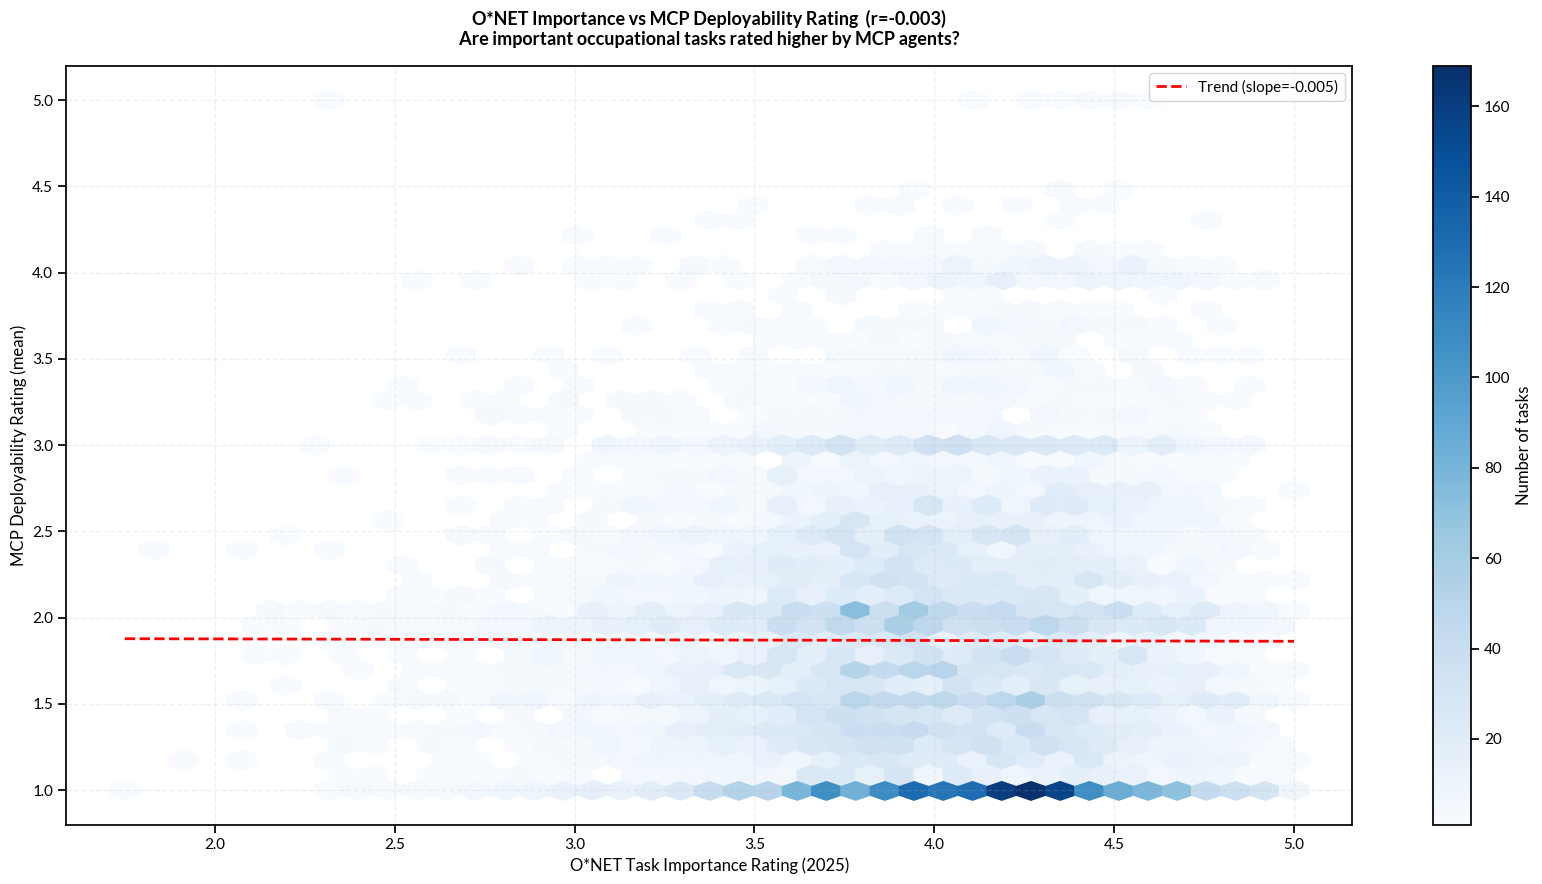

Saved: 04c_Importance_vs_MCP_Rating.png
Correlation (importance vs MCP rating): r = -0.003


In [22]:
# Do MCP agents rate more important tasks higher?
scatter_df = rated.dropna(subset=["importance_2025", "mean_rating"]).copy()

fig, ax = plt.subplots(figsize=CHART_SIZE)
ax.hexbin(scatter_df["importance_2025"], scatter_df["mean_rating"],
          gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(ax.collections[0], ax=ax, label="Number of tasks")

# Trend
z = np.polyfit(scatter_df["importance_2025"].dropna(),
               scatter_df.loc[scatter_df["importance_2025"].notna(), "mean_rating"], 1)
xline = np.linspace(scatter_df["importance_2025"].min(), scatter_df["importance_2025"].max(), 200)
ax.plot(xline, np.polyval(z, xline), 'r--', linewidth=2,
        label=f"Trend (slope={z[0]:+.3f})")

corr = scatter_df[["importance_2025", "mean_rating"]].corr().iloc[0, 1]
ax.set_xlabel("O*NET Task Importance Rating (2025)", fontsize=12)
ax.set_ylabel("MCP Deployability Rating (mean)", fontsize=12)
ax.set_title(f"O*NET Importance vs MCP Deployability Rating  (r={corr:.3f})\n"
             "Are important occupational tasks rated higher by MCP agents?",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout()

fname = "04c_Importance_vs_MCP_Rating.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")
print(f"Correlation (importance vs MCP rating): r = {corr:.3f}")

### 4d. Highest-Rated Tasks by MCP Agents

In [23]:
# Top tasks by mean MCP rating (with minimum n_ratings for reliability)
MIN_RATINGS = 100
top_tasks = (
    rated[rated["n_ratings"] >= MIN_RATINGS]
    .nlargest(20, "mean_rating")
    [["task", "title_current", "major_occ_category", "mean_rating", "n_ratings",
      "importance_2025", "a_med_nat_2024"]]
    .rename(columns={
        "task": "Task", "title_current": "Occupation",
        "major_occ_category": "Major Category",
        "mean_rating": "Mean Rating", "n_ratings": "# Ratings",
        "importance_2025": "Importance", "a_med_nat_2024": "Median Wage"
    })
)
print(f"Top 20 tasks by MCP rating (≥{MIN_RATINGS} ratings):")
display(
    top_tasks.style
    .format({"Mean Rating": "{:.2f}", "# Ratings": "{:,.0f}",
             "Importance": "{:.1f}", "Median Wage": "${:,.0f}"})
    .background_gradient(subset=["Mean Rating"], cmap="Blues")
)

Top 20 tasks by MCP rating (≥100 ratings):


,Task,Occupation,Major Category,Mean Rating,# Ratings,Importance,Median Wage
1956,"Complete work schedules, manage calendars, and arrange appointments.","Office Clerks, General",Office and Administrative Support Occupations,4.20,108,3.7,"$43,630"
2001,Schedule medical appointments for patients.,Medical Records Specialists,Healthcare Practitioners and Technical Occupations,4.14,104,4.3,"$58,486"
1549,"Receive and process payments from customers, using electronic transaction services.",Online Merchants,Business and Financial Operations Occupations,4.11,146,4.5,"$81,270"
2011,Complete form letters in response to requests or problems identified by correspondence.,Correspondence Clerks,Office and Administrative Support Occupations,3.78,101,3.4,"$46,740"
849,Maintain databases of logistics information.,Logistics Analysts,Business and Financial Operations Occupations,3.74,336,4.5,"$80,880"
1602,"Operate telephone switchboard to answer, screen, or forward calls, providing information, taking messages, or scheduling appointments.",Receptionists and Information Clerks,Office and Administrative Support Occupations,3.74,141,4.7,"$37,230"
2012,Prepare responses to correspondence containing routine inquiries.,Executive Secretaries and Executive Administrative Assistants,Office and Administrative Support Occupations,3.74,101,4.0,"$74,260"
850,Create or maintain database of customer accounts.,Online Merchants,Business and Financial Operations Occupations,3.70,336,3.9,"$81,270"
2013,Type acknowledgment letters to persons sending correspondence.,Correspondence Clerks,Office and Administrative Support Occupations,3.70,101,3.5,"$46,740"
851,Enter logistics-related data into databases.,Logistics Analysts,Business and Financial Operations Occupations,3.61,336,4.0,"$80,880"


---
# Section 5: Time Trend Analysis

Uses `mcp_results` which has `uploaded_clean` (date each MCP server was listed on mcp.so).

**Note:** The date range is Apr 2025 → Feb 2026, reflecting when servers were listed on the mcp.so registry.

### 5a. MCP Server Additions Per Month

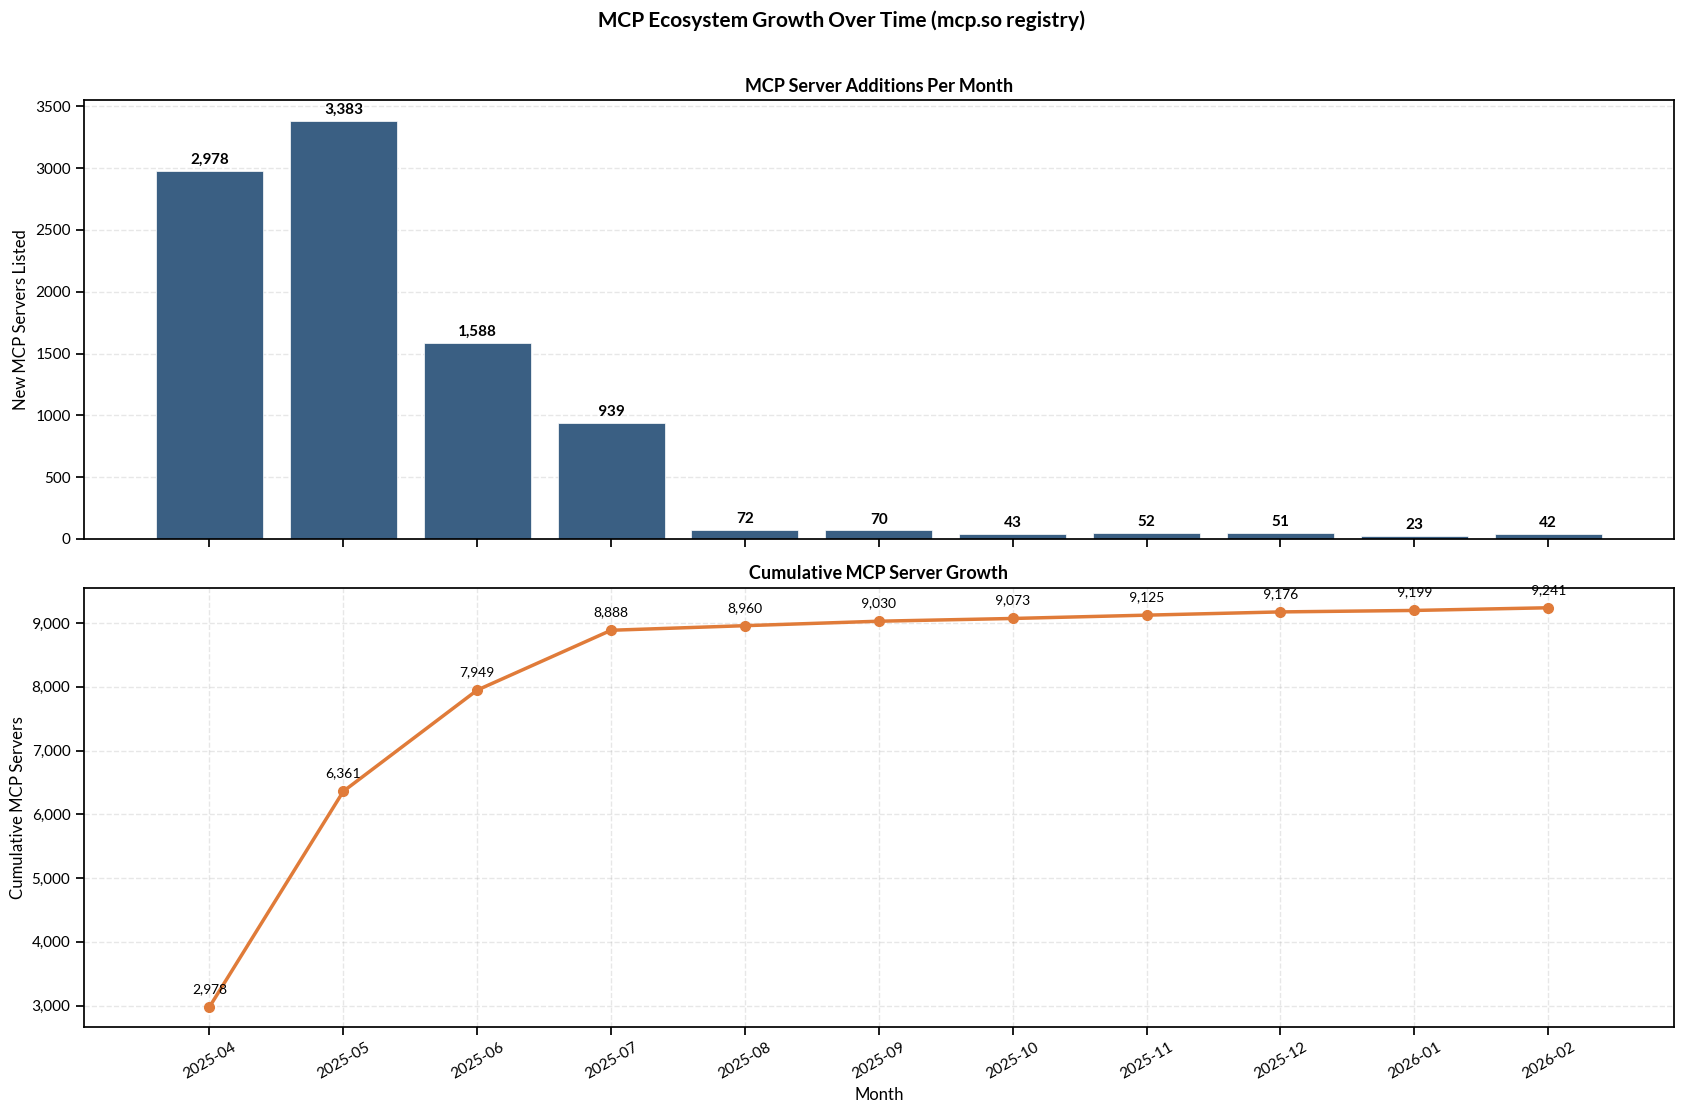

Saved: 05a_MCP_Growth_Over_Time.png


In [24]:
monthly_new = (
    results_df.dropna(subset=["upload_month"])
    .groupby("upload_month")
    .size()
    .reset_index(name="new_servers")
)
monthly_new["cumulative"] = monthly_new["new_servers"].cumsum()
monthly_new["month_str"] = monthly_new["upload_month"].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(CHART_SIZE[0], CHART_SIZE[1] + 2), sharex=True)

# Monthly new additions
bars = ax1.bar(monthly_new["month_str"], monthly_new["new_servers"],
               color=MAIN_COLOR, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, monthly_new["new_servers"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylabel("New MCP Servers Listed", fontsize=12)
ax1.set_title("MCP Server Additions Per Month", fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Cumulative
ax2.plot(monthly_new["month_str"], monthly_new["cumulative"],
         color=ACCENT_COLOR, linewidth=2.5, marker='o', markersize=7)
for x, y in zip(monthly_new["month_str"], monthly_new["cumulative"]):
    ax2.annotate(f'{y:,}', (x, y), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)
ax2.set_ylabel("Cumulative MCP Servers", fontsize=12)
ax2.set_title("Cumulative MCP Server Growth", fontsize=13, fontweight='bold')
ax2.set_xlabel("Month", fontsize=12)
ax2.tick_params(axis='x', rotation=30)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("MCP Ecosystem Growth Over Time (mcp.so registry)",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

fname = "05a_MCP_Growth_Over_Time.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

### 5b. Work Activity Coverage Trends (DWAs per Server over Time)

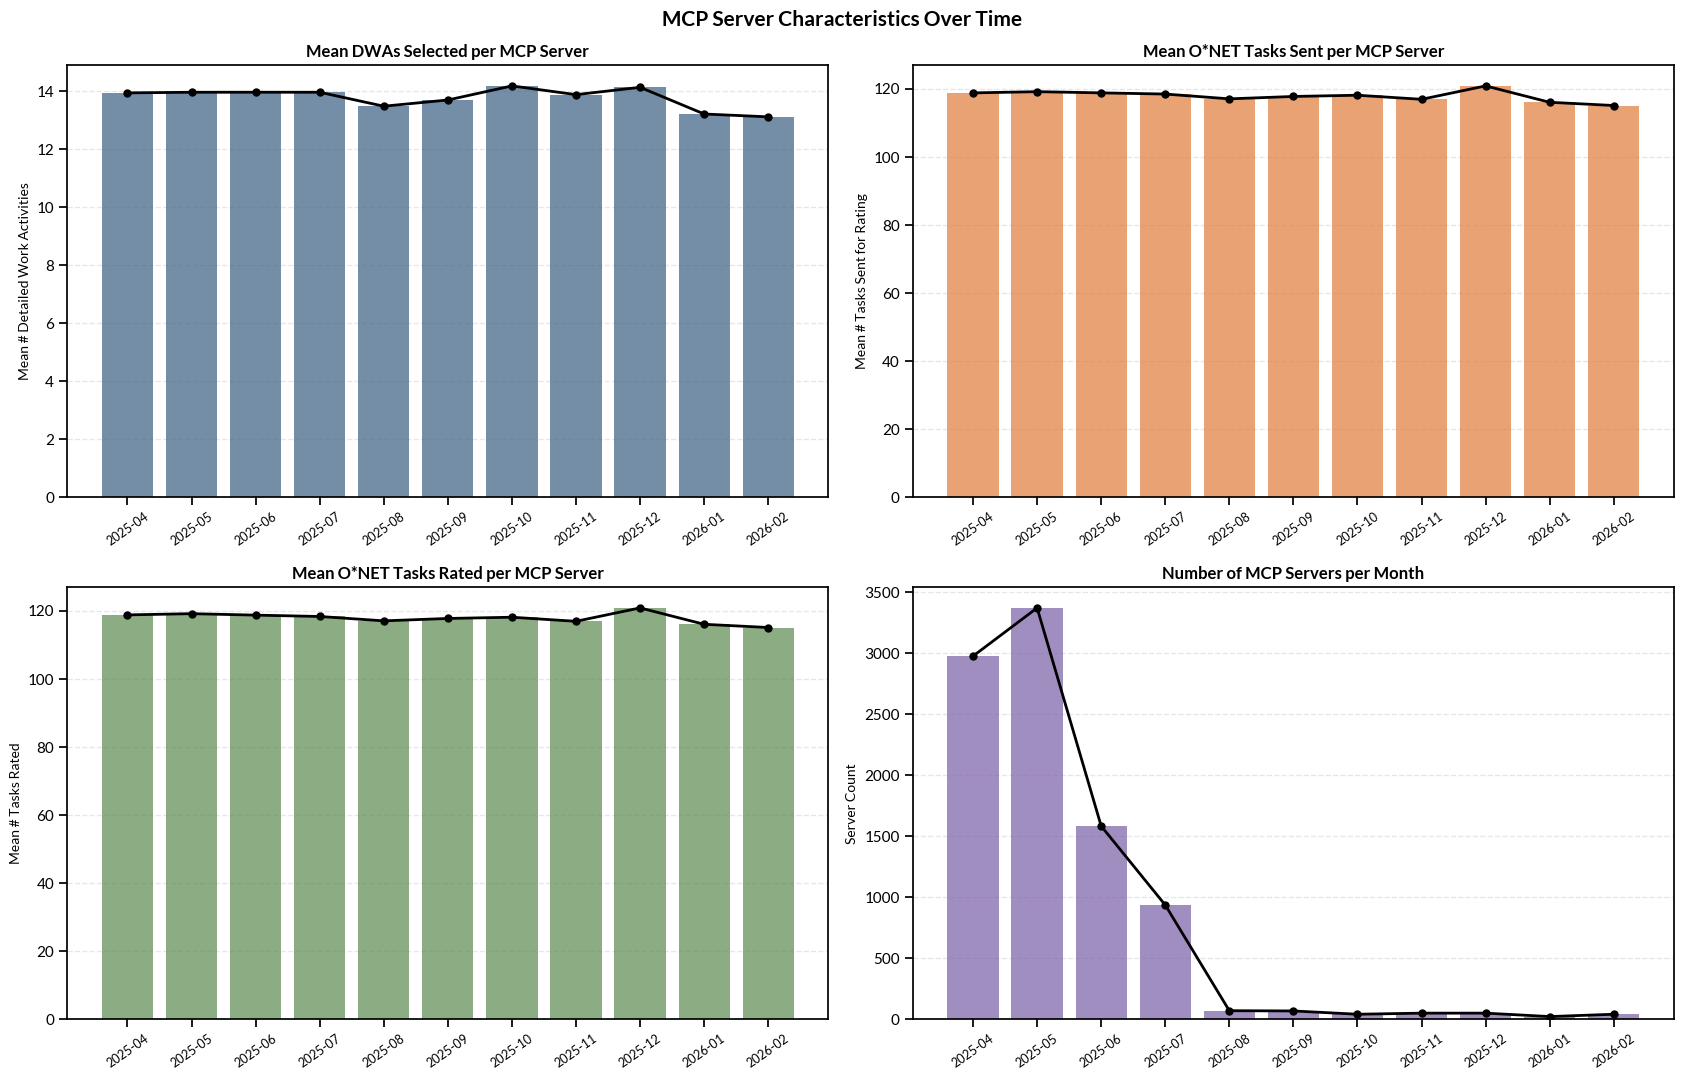

Saved: 05b_MCP_Characteristics_Over_Time.png

Monthly DWA/task stats:


,n_servers,mean_dwas,mean_tasks_sent,mean_tasks_rated
month_str,,,,
2025-04,2977.0,13.9,118.8,118.8
2025-05,3372.0,14.0,119.2,119.2
2025-06,1584.0,14.0,118.9,118.8
2025-07,937.0,14.0,118.5,118.4
2025-08,71.0,13.5,117.1,117.1
2025-09,69.0,13.7,117.8,117.8
2025-10,42.0,14.2,118.2,118.2
2025-11,51.0,13.9,117.0,117.0
2025-12,51.0,14.1,120.9,120.9


In [25]:
monthly_dwa = (
    results_df.dropna(subset=["upload_month"])
    .groupby("upload_month")
    .agg(mean_dwas=("n_dwas_selected", "mean"),
         median_dwas=("n_dwas_selected", "median"),
         mean_tasks_sent=("n_tasks_sent", "mean"),
         mean_tasks_rated=("n_tasks_rated", "mean"),
         n_servers=("title", "count"))
    .reset_index()
)
monthly_dwa["month_str"] = monthly_dwa["upload_month"].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(CHART_SIZE[0], CHART_SIZE[1] + 2))

def line_bar(ax, x, y, title, ylabel, color=MAIN_COLOR, bar=True):
    if bar:
        ax.bar(x, y, color=color, alpha=0.7)
    ax.plot(x, y, color='black', linewidth=2, marker='o', markersize=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

line_bar(axes[0,0], monthly_dwa.month_str, monthly_dwa.mean_dwas,
         "Mean DWAs Selected per MCP Server",
         "Mean # Detailed Work Activities", MAIN_COLOR)

line_bar(axes[0,1], monthly_dwa.month_str, monthly_dwa.mean_tasks_sent,
         "Mean O*NET Tasks Sent per MCP Server",
         "Mean # Tasks Sent for Rating", ACCENT_COLOR)

line_bar(axes[1,0], monthly_dwa.month_str, monthly_dwa.mean_tasks_rated,
         "Mean O*NET Tasks Rated per MCP Server",
         "Mean # Tasks Rated", "#5b8a4e")

line_bar(axes[1,1], monthly_dwa.month_str, monthly_dwa.n_servers,
         "Number of MCP Servers per Month",
         "Server Count", "#7a5ea7")

plt.suptitle("MCP Server Characteristics Over Time",
             fontsize=15, fontweight='bold')
plt.tight_layout()

fname = "05b_MCP_Characteristics_Over_Time.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")
print("\nMonthly DWA/task stats:")
display(monthly_dwa.set_index("month_str")[["n_servers", "mean_dwas", "mean_tasks_sent", "mean_tasks_rated"]]
        .style.format("{:.1f}"))

### 5c. Occupational Category Coverage Over Time

Parses `task_ratings` strings from each MCP server to extract which occupations it covers, then maps those occupations to major categories to see how coverage has evolved month by month.

In [26]:
# Build occupation → major_occ_category lookup from mcp_tasks_final
occ_to_major = (
    tasks_df[["title_current", "major_occ_category"]]
    .dropna()
    .drop_duplicates("title_current")
    .set_index("title_current")["major_occ_category"]
    .to_dict()
)
print(f"Occupation → major category lookup: {len(occ_to_major)} occupations")

# Regex to extract (occupation, rating) from task_ratings strings
# Format: "task text (Occupation Title): rating; ..."
RATING_PATTERN = re.compile(r'\(([^)]+)\):\s*(\d+(?:\.\d+)?)')

def parse_task_ratings_row(row):
    """Parse one mcp_results row → list of dicts with occupation + major category."""
    text = row["task_ratings"]
    month = row["upload_month"]
    if pd.isna(text) or pd.isna(month):
        return []
    hits = []
    for occ, rating in RATING_PATTERN.findall(str(text)):
        occ = occ.strip()
        major = occ_to_major.get(occ)
        if major:
            hits.append({"upload_month": month, "occupation": occ,
                         "major_occ_category": major, "rating": float(rating)})
    return hits

print("Parsing task_ratings for all MCP servers... (may take ~30s)")
all_hits = []
for _, row in results_df.iterrows():
    all_hits.extend(parse_task_ratings_row(row))

hits_df = pd.DataFrame(all_hits)
print(f"Done. Total (server × occupation × task) records: {len(hits_df):,}")
print(f"Unique occupations found: {hits_df['occupation'].nunique():,}")
print(f"Unique major categories found: {hits_df['major_occ_category'].nunique():,}")

Occupation → major category lookup: 921 occupations
Parsing task_ratings for all MCP servers... (may take ~30s)
Done. Total (server × occupation × task) records: 1,098,505
Unique occupations found: 919
Unique major categories found: 22


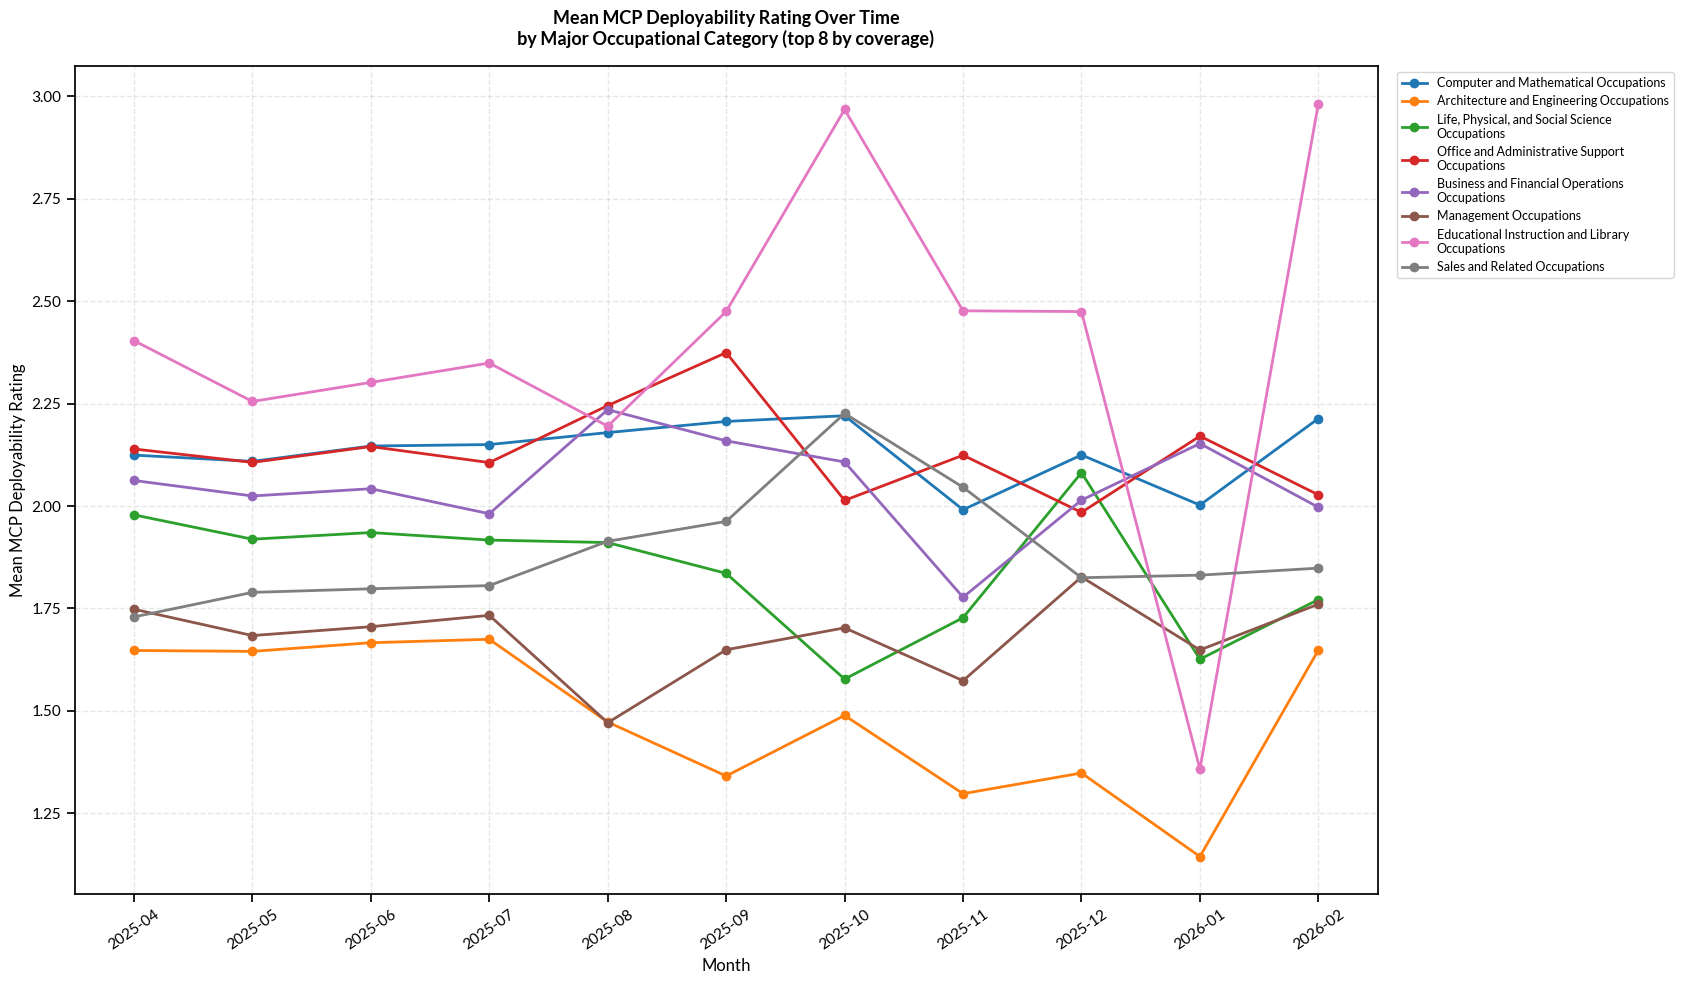

Saved: 05c_Rating_by_Category_Over_Time.png


In [27]:
# ── Monthly rating by major category ─────────────────────────
monthly_cat = (
    hits_df.groupby(["upload_month", "major_occ_category"])
    .agg(mean_rating=("rating", "mean"),
         n_hits     =("rating", "count"))
    .reset_index()
)
monthly_cat["month_str"] = monthly_cat["upload_month"].astype(str)

# Top categories by total hits for the color/label selection
top_cats_by_coverage = (
    hits_df.groupby("major_occ_category")["rating"]
    .count().nlargest(8).index.tolist()
)

fig, ax = plt.subplots(figsize=(CHART_SIZE[0], CHART_SIZE[1] + 1))
palette = sns.color_palette("tab10", len(top_cats_by_coverage))

for i, cat in enumerate(top_cats_by_coverage):
    sub = monthly_cat[monthly_cat["major_occ_category"] == cat].sort_values("upload_month")
    ax.plot(sub["month_str"], sub["mean_rating"],
            marker='o', linewidth=2, color=palette[i],
            label="\n".join(wrap(cat, 40)))

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Mean MCP Deployability Rating", fontsize=12)
ax.set_title("Mean MCP Deployability Rating Over Time\nby Major Occupational Category (top 8 by coverage)",
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=35)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = "05c_Rating_by_Category_Over_Time.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

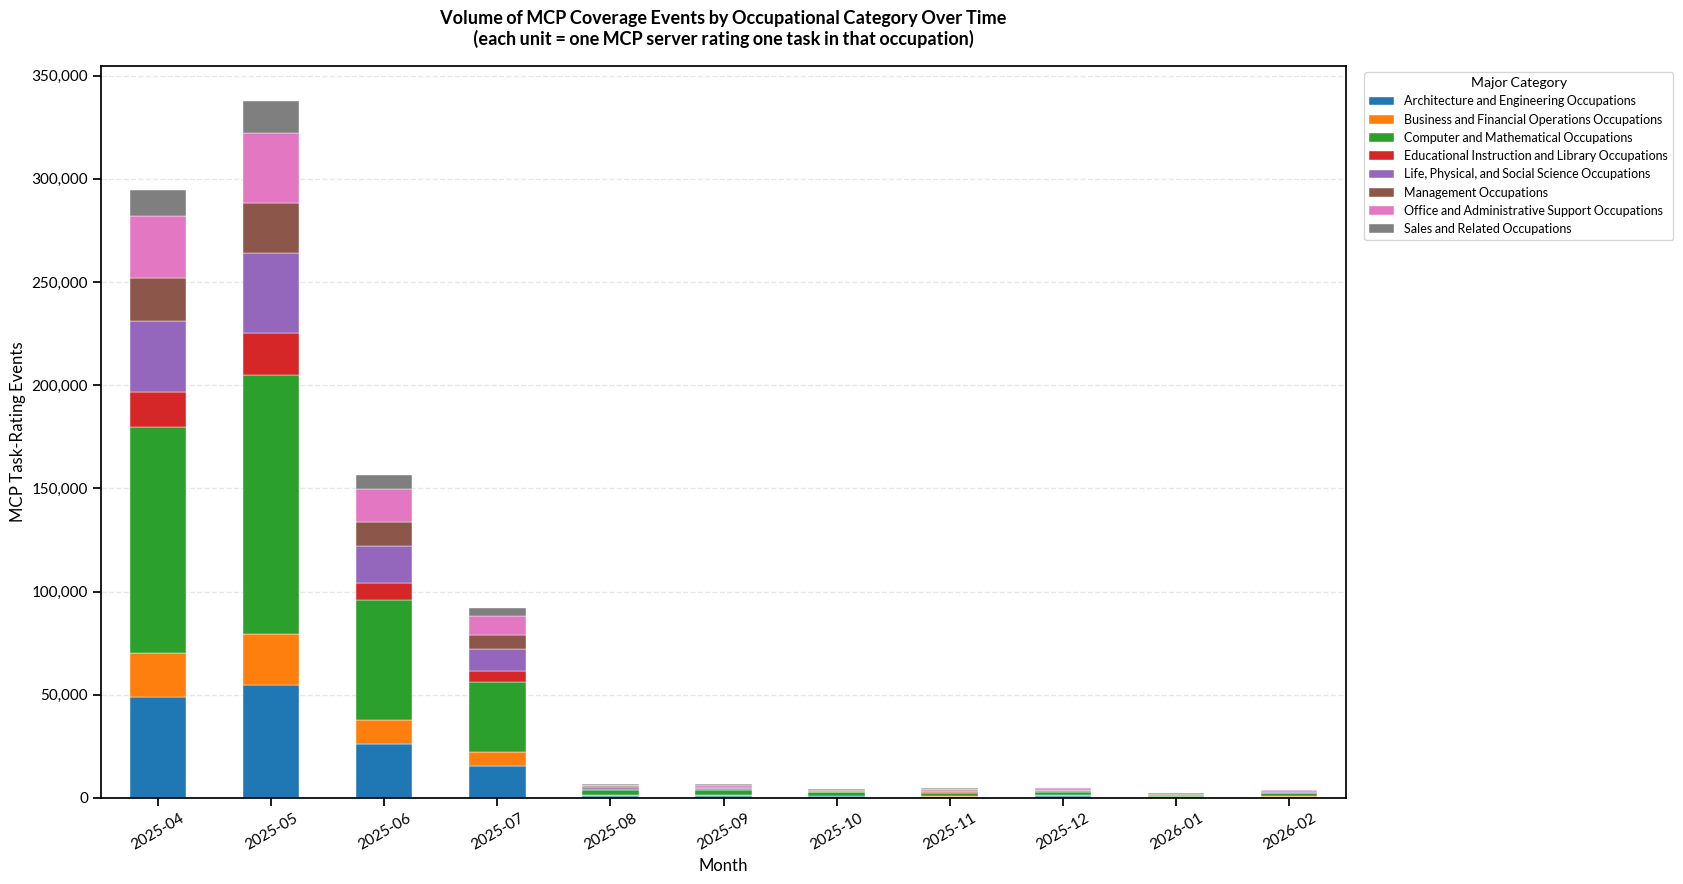

Saved: 05d_Coverage_Volume_by_Category_Over_Time.png


In [28]:
# ── Occupation coverage volume over time (stacked bar) ────────
monthly_vol = (
    hits_df[hits_df["major_occ_category"].isin(top_cats_by_coverage)]
    .groupby(["upload_month", "major_occ_category"])["rating"]
    .count()
    .unstack(fill_value=0)
)
monthly_vol.index = monthly_vol.index.astype(str)

fig, ax = plt.subplots(figsize=(CHART_SIZE[0], CHART_SIZE[1]))
monthly_vol.plot(kind='bar', stacked=True,
                 color=sns.color_palette("tab10", len(top_cats_by_coverage)),
                 ax=ax, edgecolor='white', linewidth=0.3)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("MCP Task-Rating Events", fontsize=12)
ax.set_title("Volume of MCP Coverage Events by Occupational Category Over Time\n"
             "(each unit = one MCP server rating one task in that occupation)",
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Major Category", bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title_fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = "05d_Coverage_Volume_by_Category_Over_Time.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

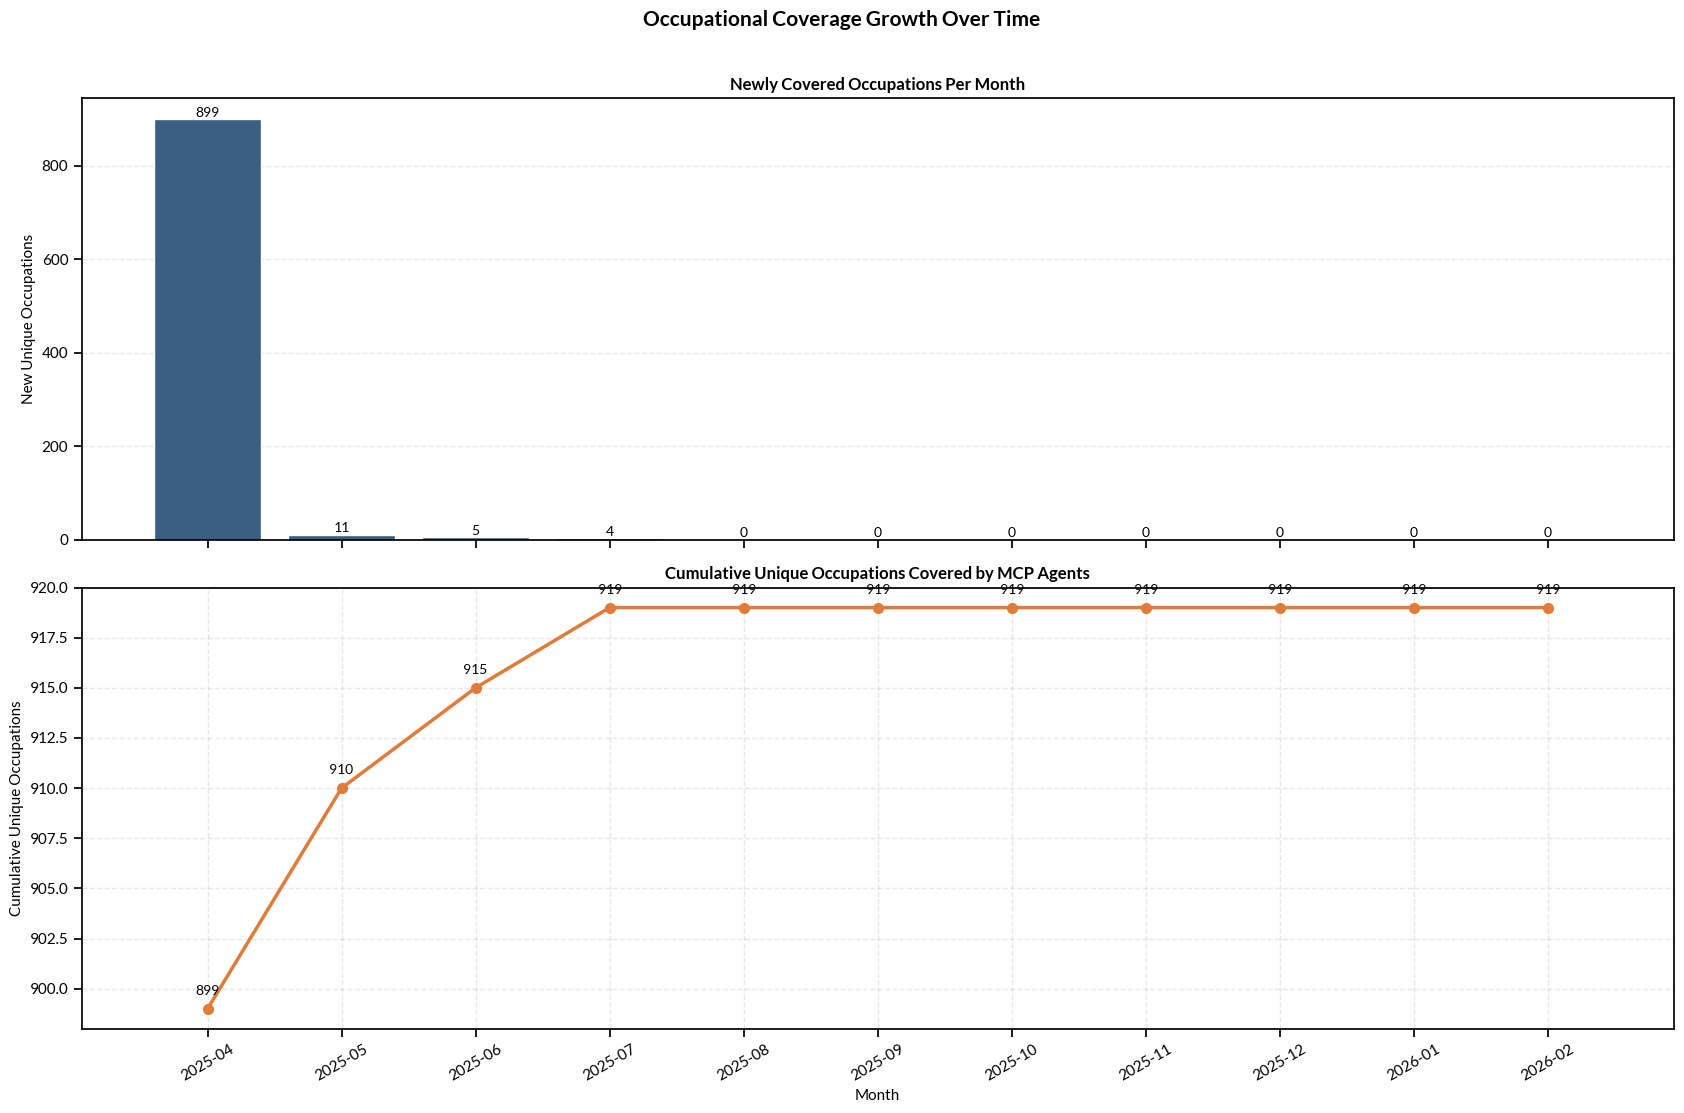

Saved: 05e_Cumulative_Occupation_Coverage.png

Total unique occupations covered across all MCP servers: 919


In [29]:
# ── Cumulative unique occupations covered over time ───────────
occ_by_month = (
    hits_df.dropna(subset=["upload_month"])
    .sort_values("upload_month")
    .groupby("upload_month")["occupation"]
    .apply(set)
    .reset_index()
)

seen = set()
cumulative_unique = []
for _, row in occ_by_month.iterrows():
    new_occs = row["occupation"] - seen
    seen |= row["occupation"]
    cumulative_unique.append({"upload_month": row["upload_month"],
                              "new_unique_occs": len(new_occs),
                              "cumulative_unique_occs": len(seen)})

cum_df = pd.DataFrame(cumulative_unique)
cum_df["month_str"] = cum_df["upload_month"].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(CHART_SIZE[0], CHART_SIZE[1] + 2), sharex=True)

ax1.bar(cum_df.month_str, cum_df.new_unique_occs, color=MAIN_COLOR, edgecolor='white')
for x, y in zip(cum_df.month_str, cum_df.new_unique_occs):
    ax1.text(x, y + 0.5, f'{y:,}', ha='center', va='bottom', fontsize=10)
ax1.set_ylabel("New Unique Occupations", fontsize=11)
ax1.set_title("Newly Covered Occupations Per Month", fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

ax2.plot(cum_df.month_str, cum_df.cumulative_unique_occs,
         color=ACCENT_COLOR, linewidth=2.5, marker='o', markersize=7)
for x, y in zip(cum_df.month_str, cum_df.cumulative_unique_occs):
    ax2.annotate(f'{y:,}', (x, y), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)
ax2.set_ylabel("Cumulative Unique Occupations", fontsize=11)
ax2.set_title("Cumulative Unique Occupations Covered by MCP Agents", fontsize=12, fontweight='bold')
ax2.set_xlabel("Month", fontsize=11)
ax2.tick_params(axis='x', rotation=30)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle("Occupational Coverage Growth Over Time",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

fname = "05e_Cumulative_Occupation_Coverage.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")
print(f"\nTotal unique occupations covered across all MCP servers: {len(seen):,}")

### 5d. Are Newer MCPs Rated Higher? (Rating Score by Upload Month)

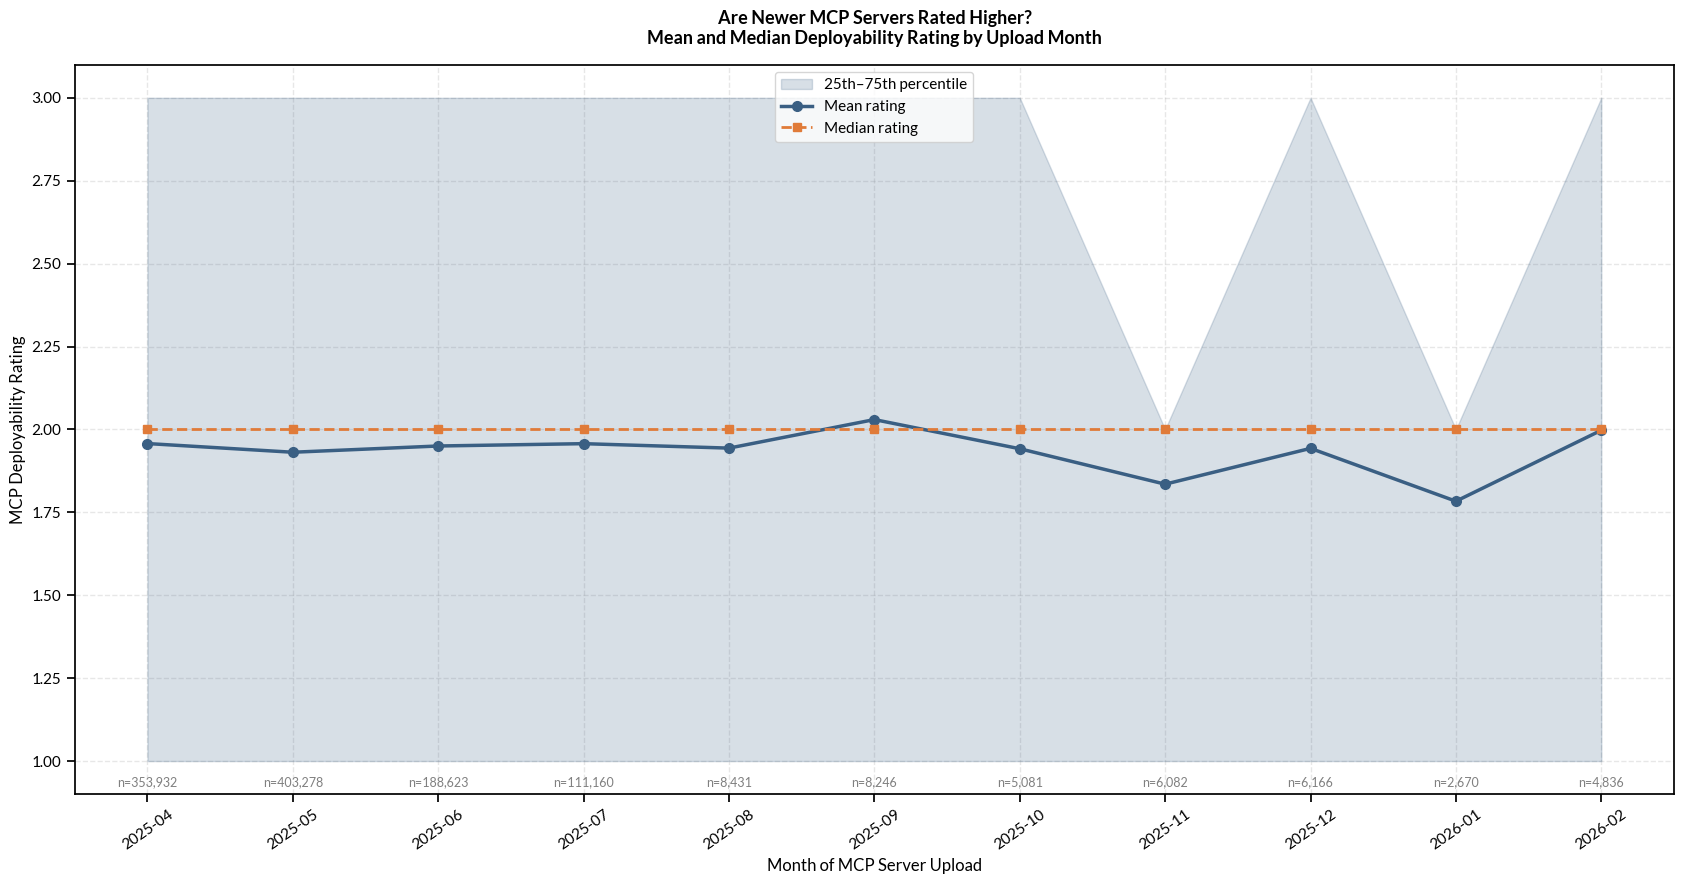

Saved: 05f_Rating_Trend_Over_Time.png

Monthly rating summary:


,mean_rating,median_rating,p25,p75,n
month_str,,,,,
2025-04,1.957396,2.000000,1.000000,3.000000,"353,932"
2025-05,1.931209,2.000000,1.000000,3.000000,"403,278"
2025-06,1.950054,2.000000,1.000000,3.000000,"188,623"
2025-07,1.957089,2.000000,1.000000,3.000000,"111,160"
2025-08,1.943660,2.000000,1.000000,3.000000,"8,431"
2025-09,2.029711,2.000000,1.000000,3.000000,"8,246"
2025-10,1.941744,2.000000,1.000000,3.000000,"5,081"
2025-11,1.834923,2.000000,1.000000,2.000000,"6,082"
2025-12,1.942913,2.000000,1.000000,3.000000,"6,166"


In [30]:
monthly_rating = (
    hits_df.dropna(subset=["upload_month"])
    .groupby("upload_month")
    .agg(mean_rating  =("rating", "mean"),
         median_rating=("rating", "median"),
         p25=("rating", lambda x: x.quantile(0.25)),
         p75=("rating", lambda x: x.quantile(0.75)),
         n  =("rating", "count"))
    .reset_index()
)
monthly_rating["month_str"] = monthly_rating["upload_month"].astype(str)

fig, ax = plt.subplots(figsize=CHART_SIZE)

ax.fill_between(monthly_rating.month_str,
                monthly_rating.p25, monthly_rating.p75,
                alpha=0.2, color=MAIN_COLOR, label="25th–75th percentile")
ax.plot(monthly_rating.month_str, monthly_rating.mean_rating,
        color=MAIN_COLOR, linewidth=2.5, marker='o', markersize=7, label="Mean rating")
ax.plot(monthly_rating.month_str, monthly_rating.median_rating,
        color=ACCENT_COLOR, linewidth=2, linestyle='--', marker='s', markersize=6,
        label="Median rating")

# Annotate n per month
for _, row in monthly_rating.iterrows():
    ax.annotate(f'n={row.n:,.0f}', (row.month_str, row.p25),
                textcoords="offset points", xytext=(0, -18),
                ha='center', fontsize=9, color='gray')

ax.set_xlabel("Month of MCP Server Upload", fontsize=12)
ax.set_ylabel("MCP Deployability Rating", fontsize=12)
ax.set_title("Are Newer MCP Servers Rated Higher?\n"
             "Mean and Median Deployability Rating by Upload Month",
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

fname = "05f_Rating_Trend_Over_Time.png"
plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {fname}")

print("\nMonthly rating summary:")
display(monthly_rating.set_index("month_str")[["mean_rating", "median_rating", "p25", "p75", "n"]]
        .style.format("{:.2f}").format({"n": "{:,.0f}"}))

---
# Summary: All Charts Generated

In [31]:
saved = sorted(glob(os.path.join(OUTPUT_DIR, "*.png")))
print(f"\n{'='*60}")
print(f"Variant used: {DEFAULT_VARIANT}")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"{'='*60}")
print(f"\nCharts saved ({len(saved)} total):")
for f in saved:
    print(f"  {os.path.basename(f)}")


Variant used: max_ge_5
Output directory: c:\Users\teddy\Downloads\OAIPR\Technical\automation_exposure_analysis\outputs\mcp_charts

Charts saved (30 total):
  01a_Workers_by_Occ_Category_National_max_ge_4.png
  01a_Workers_by_Occ_Category_National_max_ge_5.png
  01b_Workers_by_Occ_Category_Utah_max_ge_4.png
  01b_Workers_by_Occ_Category_Utah_max_ge_5.png
  01c_Top_Occupations_National_max_ge_4.png
  01c_Top_Occupations_National_max_ge_5.png
  01d_Top_Occupations_Utah_max_ge_4.png
  01d_Top_Occupations_Utah_max_ge_5.png
  01e_Wages_by_Occ_Category_National_max_ge_4.png
  01e_Wages_by_Occ_Category_National_max_ge_5.png
  01f_Wages_by_Occ_Category_Utah_max_ge_4.png
  01f_Wages_by_Occ_Category_Utah_max_ge_5.png
  02a_Variant_Totals_Comparison.png
  03a_Automation_Rate_Distribution_max_ge_4.png
  03a_Automation_Rate_Distribution_max_ge_5.png
  03b_Automation_vs_Wage_Scatter_max_ge_4.png
  03b_Automation_vs_Wage_Scatter_max_ge_5.png
  03c_Top_Occupations_by_Automation_Rate_max_ge_4.png
  03c